In [1]:
import os
import math
import pandas as pd
import numpy as np
import torch  
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader  
from tensorflow.keras.preprocessing import text, sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader  

import time

import pickle
import json

2024-12-19 21:52:50.100135: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-19 21:52:52.146658: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def data_reader(base_path='.', 
                       pp_csv_file='/large_PP.csv', 
                       target_min_size=1,
                       target_size=250,
                       test_split=0.05, 
                       num_AA=22, 
                       num_SS=10,
                       batch_size_=64):
    
    #csv reader
    df = pd.read_csv(base_path + pp_csv_file)
    print(df.head())
    pp_df = df[df['seq_len'].between(target_min_size, target_size)]
    print('num of seq:', len(pp_df))
    # print(pp_df.memory_usage().sum())
    pp_seqs = pp_df.sequence.values
    pp_ss_seqs = pp_df.Secstructure.values
    lengths = [int(seq_len) for seq_len in pp_df.seq_len.values]
    max_length = max(lengths)
    min_length = min(lengths)
    print('max_length:{max}, min_length:{min}'.format(max=max_length, min=min_length))
    tokenizer_X_file = 'tokenizer_X.pickle'  
    tokenizer_y_file = 'tokenizer_y.pickle'    
    # 使用pickle加载Tokenizer模型  
    with open(tokenizer_X_file, 'rb') as f:  
        tokenizer_X = pickle.load(f)  
    with open(tokenizer_y_file, 'rb') as f:  
        tokenizer_y = pickle.load(f)  

    # tokenizer_X = Tokenizer(char_level=True, filters='!"$%&()*+,./:;<=>?[\\]^_`{|}\t\n' ) # retain -, - means no Secondary Structure
    # tokenizer_X.fit_on_texts(pp_ss_seqs)
    X = tokenizer_X.texts_to_sequences(pp_ss_seqs)
    X = sequence.pad_sequences(X, maxlen=max_length, padding='post', truncating='post')  
    print (">>>>>>>>config of X")
    #将返回一个包含模型配置的 Python 字典
    config_X = tokenizer_X.get_config()
    print(config_X)

    #统计词汇个数
    num_words_X = len(tokenizer_X.word_index) + 1
    print(">>>>>>>>number of vocabulary_X: ", num_words_X)
    print(">>>>>>>>first 5 sequence_X: ", X[:5, :])
    print(">>>>>>>>X shape: ", X.shape)
    
    # reversed SS sequence
    X_reversed = tokenizer_X.sequences_to_texts(X)
    for index in range(len(X_reversed)):
        #大写去前后空格去内部空格
            X_reversed[index] = X_reversed[index].upper().strip().replace(" ", "")
    
    #示例序列输出    
    print(">>>>>>>>Number of reversed X sequences: ", len(X_reversed))
    print(">>>>>>>>First 5 reversed X sequences: ", X_reversed[0:5])
    print(">>>>>>>>Length of first X sequence as example: ", len(X_reversed[0]) )
    # sequence
    # tokenizer_y = Tokenizer(char_level=True, filters='!"$%&()*+,-./:;<=>?[\\]^_`{|}\t\n' ) 
    # tokenizer_y.fit_on_texts(pp_seqs)
    y = tokenizer_y.texts_to_sequences(pp_seqs)
    y = sequence.pad_sequences(y, maxlen=max_length, padding='post', truncating='post')  

    print (">>>>>>>>config of y")
    #将返回一个包含模型配置的 Python 字典
    config_y = tokenizer_y.get_config()
    print(config_y)
    
    #统计词汇个数
    num_words_y = len(tokenizer_y.word_index) + 1
    print(">>>>>>>>number of vocabulary: ", num_words_y)
    print(">>>>>>>>first 5 sequence: ", y[:5, :])
    print(">>>>>>>>y shape: ", y.shape)
    
    # reversed sequence
    y_reversed = tokenizer_y.sequences_to_texts(y)
    for index in range(len(y_reversed)):
        #大写去前后空格去内部空格
        y_reversed[index] = y_reversed[index].upper().strip().replace(" ", "")
    
    #示例序列输出    
    print(">>>>>>>>Number of reversed sequences: ", len(y_reversed))
    print(">>>>>>>>First 5 reversed sequences: ", y_reversed[0:5])
    print(">>>>>>>>Length of first sequence as example: ", len(y_reversed[0]) )

    #train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=123)

    # X_train_part1, X_train_part2, y_train_part1, y_train_part2 = train_test_split(X_train, y_train, test_size=0.8, random_state=123)


    #train/test loader
    # train_dataset = PPContactDataset(torch.from_numpy(X_train_part).float()/num_SS, torch.from_numpy(y_train_part).float()/num_AA)
    # train_loader_shuffle = DataLoader(dataset=train_dataset, batch_size=batch_size_, shuffle=True)
    # train_loader_noshuffle = DataLoader(dataset=train_dataset, batch_size=batch_size_, shuffle=False)

    
    # train_dataset_1 = PPContactDataset(torch.from_numpy(X_train_part1).float()/num_SS, torch.from_numpy(y_train_part1).float()/num_AA)
    # train_loader_shuffle_1 = DataLoader(dataset=train_dataset_1, batch_size=batch_size_, shuffle=True)
    # train_loader_noshuffle_1 = DataLoader(dataset=train_dataset_1, batch_size=batch_size_, shuffle=False)

    # train_dataset_2 = PPContactDataset(torch.from_numpy(X_train_part2).float()/num_SS, torch.from_numpy(y_train_part2).float()/num_AA)
    # train_loader_shuffle_2 = DataLoader(dataset=train_dataset_2, batch_size=batch_size_, shuffle=True)
    # train_loader_noshuffle_2 = DataLoader(dataset=train_dataset_2, batch_size=batch_size_, shuffle=False)
    
    test_dataset = PPContactDataset(torch.from_numpy(X_test).float()/num_SS, torch.from_numpy(y_test).float()/num_AA)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size_)
    
    # val_dataset = PPContactDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float()/num_AA)
    # val_loader = DataLoader(dataset=test_dataset, batch_size=batch_size_)

    # return train_loader_shuffle, train_loader_noshuffle, test_loader, tokenizer_X, tokenizer_y 
    return X_train, y_train, test_dataset, test_loader, tokenizer_X, tokenizer_y 

    
class PPContactDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data
        
    def __len__ (self):
        return len(self.X_data)

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]    
    
def split_train_set(X_train, y_train, train_size, random_state, num_SS=10, num_AA=22, batch_size_=128):
    X_train_part1, X_train_drop, y_train_part1, y_train_drop = train_test_split(X_train, y_train, test_size=1-train_size, random_state=random_state)
    train_dataset = PPContactDataset(torch.from_numpy(X_train_part1).float()/num_SS, torch.from_numpy(y_train_part1).float()/num_AA)
    train_loader_shuffle = DataLoader(dataset=train_dataset, batch_size=batch_size_, shuffle=True)
    train_loader_noshuffle = DataLoader(dataset=train_dataset, batch_size=batch_size_, shuffle=False)

    return train_loader_shuffle, train_loader_noshuffle



In [3]:
X_train, y_train, test_dataset, test_loader, tokenizer_X, tokenizer_y = data_reader()


  name1 name2  seq_len                                           sequence  \
0  4TTP     A      201  MVYSVGLTGNIASGKSTVAEFFSELGINVIYADKIAKELTSKNTPC...   
1  2C79     A      205  KLVALTFDDGPDNVLTARVLDKLDKYNVKATFMVVGQRVNDSTAAI...   
2  6VHB     A        7                                            GSNQNNF   
3  6RND     A      387  NYQPTPEDRFTFGLWTVGWQGRDPFGDATRRALDPVESVRRLAELG...   
4  3ILO     A      158  TVAYIAIGSNLASPLEQVNAALKALGDIPESHILTVSSFYRTPPLG...   

       distance_path       contact_path  \
0  ./dist/4TTP_A.npy  ./cont/4TTP_A.npy   
1  ./dist/2C79_A.npy  ./cont/2C79_A.npy   
2  ./dist/6VHB_A.npy  ./cont/6VHB_A.npy   
3  ./dist/6RND_A.npy  ./cont/6RND_A.npy   
4  ./dist/3ILO_A.npy  ./cont/3ILO_A.npy   

                                        Secstructure  
0  ---EEEEEE-GGGTHHHHHHHHHTTT-EEEEHHHHHHHHTSTT-HH...  
1  -EEEEEEEEE--HHHHHHHHHHHHHHT---EEEE-GGG-SGGGHHH...  
2                                            -------  
3  -----GGG-EEEEHHHHT----BTTB---S----HHHHHHHHHHHT...  
4  

In [4]:
def count_parameters(model, count_all=False):
    if count_all == False:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    else:
        return sum(p.numel() for p in model.parameters())

In [7]:
from autoencoder_1 import condition_process,Unet_1d

In [8]:
import copy
from math import sqrt
from random import random
from functools import partial
from contextlib import contextmanager, nullcontext
from typing import List, Union
from collections import namedtuple
from tqdm.auto import tqdm
from functools import partial, wraps

import torch
import torch.nn.functional as F
from torch import nn
from torch.cuda.amp import autocast
from torch.nn.parallel import DistributedDataParallel
import torchvision.transforms as T

import kornia.augmentation as K

from einops import rearrange, repeat, reduce

# helper functions
#写一些辅助函数可以装饰后续函数

#判断变量是否是None，True是非空变量
def exists(val):
    return val is not None

def identity(t, *args, **kwargs):
    return t

#输出数组第一元素，若数组长度为0则输出None
def first(arr, d = None):
    if len(arr) == 0:
        return d
    return arr[0]

#wraps是functiontool函数
#可以保证装饰器修饰的函数的__name__的值和__doc__保持不变
#装饰函数，非空变量会输出代入函数值，空变量则直接返回
def maybe(fn):
    @wraps(fn)
    def inner(x):
        if not exists(x):
            return x
        return fn(x)
    return inner

#装饰函数，调用一次函数，未调用则调用一次，调用过则返回空值
def once(fn):
    called = False
    @wraps(fn)
    def inner(x):
        #nonlocal声明外部嵌套函数内的变量
        nonlocal called
        if called:
            return
        called = True
        return fn(x)
    return inner

#打印一次测试
print_once = once(print)

#pass
#exist判断变量是否是None，True是非空变量
#callable() 函数用于检查一个对象是否是可调用的
def default(val, d):
    if exists(val):
        return val
    return d() if callable(d) else d

#给list变量套个tuple
def cast_tuple(val, length = None):
    #isinstance(object, classinfo) 函数来判断一个对象是否是一个已知的类型，类似 type()
    #isinstance() 会认为子类是一种父类类型，考虑继承关系。
    if isinstance(val, list):
        val = tuple(val)

    output = val if isinstance(val, tuple) else ((val,) * default(length, 1))

    if exists(length):
        assert len(output) == length

    return output

#判断list内元素type是否是float
def is_float_dtype(dtype):
    return any([dtype == float_dtype for float_dtype in (torch.float64, torch.float32, torch.float16, torch.bfloat16)])

#8位图转rgb255图
def cast_uint8_images_to_float(images):
    if not images.dtype == torch.uint8:
        return images
    return images / 255

#tensor所在位置gpu/cpu
def module_device(module):
    return next(module.parameters()).device

#模型参数初始化0
def zero_init_(m):
    nn.init.zeros_(m.weight)
    if exists(m.bias):
        nn.init.zeros_(m.bias)

#装饰函数，用于评估模型
def eval_decorator(fn):
    def inner(model, *args, **kwargs):
        was_training = model.training
        model.eval()
        out = fn(model, *args, **kwargs)
        model.train(was_training)
        return out
    return inner

#把tuple t填满到length长度，填充空字符
def pad_tuple_to_length(t, length, fillvalue = None):
    remain_length = length - len(t)
    if remain_length <= 0:
        return t
    return (*t, *((fillvalue,) * remain_length))

# helper classes
#定义辅助类
class Identity(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__()

    def forward(self, x, *args, **kwargs):
        return x

# tensor helpers
#对张量处理的辅助函数

#tensor取自然对数
#clamp（）函数的功能将输入input张量每个元素的值压缩到区间 [min,max]，并返回结果到一个新张量
def log(t, eps: float = 1e-12):
    return torch.log(t.clamp(min = eps))

#L2范数对行归一化，默认2范数
#维度记忆技巧:最后一个维度始终是行，从后向前推:行、列、通道
def l2norm(t):
    return F.normalize(t, dim = -1)

#比较左右张量，给右边张量打扩维补丁？
def right_pad_dims_to(x, t):
    #ndim返回的是数组的维度，返回的只有一个数，该数即表示数组的维度。
    padding_dims = x.ndim - t.ndim
    if padding_dims <= 0:
        return t
    #该函数返回一个有__相同数据__但不同尺寸的 Tensor。通俗一点，就是__改变矩阵维度
    #在形参前加'*'表示可以接受多个实参值存进数组
    #列表或元组前面加星号作用是将列表解开成独立的参数，传入函数；
    #比如原t尺寸（3，3），升4维以后（3，3，1，1），相当于尺寸后面加升维数的1
    #*代表解包实参
    return t.view(*t.shape, *((1,) * padding_dims))

#掩膜
#Python 3 中可以定义一种只能以关键字形式来指定的参数，从而确保调用该函数的代码读起来会比较明确。
#这些参数必须以关键字的形式提供，而不能按位置提供。
#参数列表里的 * 星号，标志着位置参数的就此终结，之后的那些参数，都只能以关键字形式来指定
def masked_mean(t, *, dim, mask = None):
    if not exists(mask):
        return t.mean(dim = dim)

    denom = mask.sum(dim = dim, keepdim = True)
    #升维(b,n) to (b,n,1)
    mask = rearrange(mask, 'b n -> b n 1')
    masked_t = t.masked_fill(~mask, 0.)

    return masked_t.sum(dim = dim) / denom.clamp(min = 1e-5)


#resize原图尺寸到新尺寸
def resize_image_to(
    image,
    target_image_size,
    clamp_range = None
):
    orig_image_size = image.shape[-1]

    if orig_image_size == target_image_size:
        return image
    #利用插值方法，对输入的张量数组进行上\下采样操作，换句话说就是科学合理地改变数组的尺寸大小，尽量保持数据完整
    out = F.interpolate(image.float(), target_image_size, mode = 'linear', align_corners = True) 

    return out


# image normalization functions
# ddpms expect images to be in the range of -1 to 1
def normalize_neg_one_to_one(img):
    return img * 2 - 1

#图片张量反归一化
def unnormalize_zero_to_one(normed_img):
    return (normed_img + 1) * 0.5

# classifier free guidance functions

def prob_mask_like(shape, prob, device):
    if prob == 1:
        return torch.ones(shape, device = device, dtype = torch.bool)
    elif prob == 0:
        return torch.zeros(shape, device = device, dtype = torch.bool)
    else:
        return torch.zeros(shape, device = device).float().uniform_(0, 1) < prob

# gaussian diffusion with continuous time helper functions and classes
# large part of this was thanks to @crowsonkb at https://github.com/crowsonkb/v-diffusion-jax/blob/master/diffusion/utils.py

#torch.jit.script脚本化一个函数或者nn.Module对象，将会检查它的源代码， 将其作为TorchScript代码使用TorchScrit编译器编译它，返回一个ScriptModule或ScriptFunction
#推测根据扩散时长t计算噪音权重alpha和beta,双模式线性或者cos
#snr信噪比？代表扩散过程中，噪音和原数据的权重？
@torch.jit.script
def beta_linear_log_snr(t):#planA
    return -torch.log(torch.special.expm1(1e-4 + 10 * (t ** 2)))#torch.special.expm1指数化-1

@torch.jit.script
def alpha_cosine_log_snr(t, s: float = 0.008):#planB
    return -torch.log((torch.cos((t + s) / (1 + s) * torch.pi * 0.5).pow(-2)) - 1) # not sure if this accounts for beta being clipped to 0.999 in discrete version

#sigmoid激活log_snr
def log_snr_to_alpha_sigma(log_snr):
    return torch.sqrt(torch.sigmoid(log_snr)), torch.sqrt(torch.sigmoid(-log_snr))

class GaussianDiffusionContinuousTimes(nn.Module):
    def __init__(self, *, noise_schedule, timesteps = 1000):
        super().__init__()
        #双模式加噪音

        if noise_schedule == "linear":
            #都是函数，在上面定义的
            self.log_snr = beta_linear_log_snr
        elif noise_schedule == "cosine":
            self.log_snr = alpha_cosine_log_snr
        else:
            raise ValueError(f'invalid noise schedule {noise_schedule}')
        #扩散时间默认1000
        self.num_timesteps = timesteps
    
    #创建一个batch_size尺寸张量，填充noise_level
    def get_times(self, batch_size, noise_level, *, device):
        return torch.full((batch_size,), noise_level, device = device, dtype = torch.float32)
    #为什么训练过程中每一次引入的是随机时间步长 t
    #训练过程中 loss 会逐渐降低，越到后面 loss 的变化幅度越小。如果时间步长 
    #是递增的，那么必然会使得模型过多的关注较早的时间步长（因为早期 loss 大），而忽略了较晚的时间步长信息
    #创建一个batch_size尺寸张量，从0-0.999均匀分布sample
    def sample_random_times(self, batch_size, max_thres = 0.999, *, device):
        return torch.zeros((batch_size,), device = device).float().uniform_(0, max_thres)
    
    #装饰函数maybe，非空变量会输出代入函数值，空变量则直接返回
    #根据上个函数sample出的times（0-1）算出权重参数？
    def get_condition(self, times):
        return maybe(self.log_snr)(times)

    def get_sampling_timesteps(self, batch, *, device):
        #返回一个1维张量，包含在区间start和end上均匀间隔的step个点。输出张量的长度由steps决定。
        times = torch.linspace(1., 0., self.num_timesteps + 1, device = device)
        #用于对张量的某一个维度进行复制，可用于替换pytorch中的repeat
        #将一维t扩增二维，相当于把times行复制batch次，尺寸（batch， times）
        times = repeat(times, 't -> b t', b = batch)
        #沿着一个新维度对输入张量序列进行连接。 序列中所有的张量都应该为相同形状。
        #浅显说法：把多个2维的张量凑成一个3维的张量；多个3维的凑成一个4维的张量…以此类推，也就是在增加新的维度进行堆叠。
        #shape (2, batch, times)
        #[tensor_1, tensor_2,..]或者(tensor_1, tensor_2,..)，且必须tensor_1.shape == tensor_2.shape
        #0-999，和1-1000
        times = torch.stack((times[:, :-1], times[:, 1:]), dim = 0)
        #最后维度（行）上进行拆分，切片，不改变原来的tensor的shape，只是返回展开后的切片
        times = times.unbind(dim = -1)
        return times
    
    #类似编码器先验q(zt|x)?
    #之前定义的default辅助函数
    #xstart原图，xt噪音图
    #若没有安排tnext则按函数lambda计算tnext
    def q_posterior(self, x_start, x_t, t, *, t_next = None):
        t_next = default(t_next, lambda: (t - 1. / self.num_timesteps).clamp(min = 0.))
        # clamp（）函数的功能将输入input张量每个元素的值压缩到区间 [min,max],min：限制范围下限；扩散时间默认1000
        """ https://openreview.net/attachment?id=2LdBqxc1Yv&name=supplementary_material """
        log_snr = self.log_snr(t)
        log_snr_next = self.log_snr(t_next)
        #functiontool.patial,固定x_t参数，给函数打补丁补全维度，log_snr, log_snr_next
        #对比x_t，给升维log_snr, log_snr_next
        log_snr, log_snr_next = map(partial(right_pad_dims_to, x_t), (log_snr, log_snr_next))

        alpha, sigma = log_snr_to_alpha_sigma(log_snr)
        alpha_next, sigma_next = log_snr_to_alpha_sigma(log_snr_next)

        # c - as defined near eq 33
        c = -expm1(log_snr - log_snr_next)
        posterior_mean = alpha_next * (x_t * (1 - c) / alpha + c * x_start)

        # following (eq. 33)
        posterior_variance = (sigma_next ** 2) * c
        posterior_log_variance_clipped = log(posterior_variance, eps = 1e-20)
        return posterior_mean, posterior_variance, posterior_log_variance_clipped
    #重参数化技巧，由先验分布sample一个
    def q_sample(self, x_start, t, noise = None):
        dtype = x_start.dtype
        #isinstance(object, classinfo) 函数来判断一个对象是否是一个已知的类型，类似 type()

        if isinstance(t, float):
            batch = x_start.shape[0]
            #形状(batch,)，用t填充
            t = torch.full((batch,), t, device = x_start.device, dtype = dtype)
        #返回一个和输入大小相同的张量，其由均值为0、方差为1的标准正态分布填充
        #reparametrize，sample一个和x0一样尺寸的N(0,1)
        noise = default(noise, lambda: torch.randn_like(x_start))
        log_snr = self.log_snr(t).type(dtype)
        log_snr_padded_dim = right_pad_dims_to(x_start, log_snr)
        alpha, sigma =  log_snr_to_alpha_sigma(log_snr_padded_dim)

        return alpha * x_start + sigma * noise, log_snr
    #从xi sample一个到xj
    def q_sample_from_to(self, x_from, from_t, to_t, noise = None):
        shape, device, dtype = x_from.shape, x_from.device, x_from.dtype
        batch = shape[0]

        if isinstance(from_t, float):
            from_t = torch.full((batch,), from_t, device = device, dtype = dtype)

        if isinstance(to_t, float):
            to_t = torch.full((batch,), to_t, device = device, dtype = dtype)

        noise = default(noise, lambda: torch.randn_like(x_from))

        log_snr = self.log_snr(from_t)
        log_snr_padded_dim = right_pad_dims_to(x_from, log_snr)
        alpha, sigma =  log_snr_to_alpha_sigma(log_snr_padded_dim)

        log_snr_to = self.log_snr(to_t)
        log_snr_padded_dim_to = right_pad_dims_to(x_from, log_snr_to)
        alpha_to, sigma_to =  log_snr_to_alpha_sigma(log_snr_padded_dim_to)

        return x_from * (alpha_to / alpha) + noise * (sigma_to * alpha - sigma * alpha_to) / alpha
    #去噪
    def predict_start_from_noise(self, x_t, t, noise):
        log_snr = self.log_snr(t)
        log_snr = right_pad_dims_to(x_t, log_snr)
        alpha, sigma = log_snr_to_alpha_sigma(log_snr)
        return (x_t - sigma * noise) / alpha.clamp(min = 1e-8)

/work/home/af2/miniconda3/envs/cont_diffusion/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /work/home/af2/miniconda3/envs/cont_diffusion/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")


In [9]:
# null unet

class NullUnet(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__()
        self.lowres_cond = False
        self.dummy_parameter = nn.Parameter(torch.tensor([0.]))

    def cast_model_parameters(self, *args, **kwargs):
        return self

    def forward(self, x, *args, **kwargs):
        return x

In [10]:
# constants

Hparams_fields = [
    'num_sample_steps',
    'sigma_min',
    'sigma_max',
    'sigma_data',
    'rho',
    'P_mean',
    'P_std',
    'S_churn',
    'S_tmin',
    'S_tmax',
    'S_noise'
]

Hparams = namedtuple('Hparams', Hparams_fields)

# helper functions

def log(t, eps = 1e-20):
    return torch.log(t.clamp(min = eps))

# main class

class ElucidatedImagen(nn.Module):
    def __init__(
        self,
        unets,
        *,
        image_sizes,                                # for cascading ddpm, image size at each stage
        text_encoder_name = '',
        text_embed_dim =512,
        channels = 3,
        channels_out=3,
        cond_drop_prob = 0.1,
        random_crop_sizes = None,
        lowres_sample_noise_level = 0.2,            # in the paper, they present a new trick where they noise the lowres conditioning image, and at sample time, fix it to a certain level (0.1 or 0.3) - the unets are also made to be conditioned on this noise level
        per_sample_random_aug_noise_level = False,  # unclear when conditioning on augmentation noise level, whether each batch element receives a random aug noise value - turning off due to @marunine's find
        condition_on_text = True,
        auto_normalize_img = True,                  # whether to take care of normalizing the image from [0, 1] to [-1, 1] and back automatically - you can turn this off if you want to pass in the [-1, 1] ranged image yourself from the dataloader
        dynamic_thresholding = True,
        dynamic_thresholding_percentile = 0.95,     # unsure what this was based on perusal of paper
        only_train_unet_number = None,
        lowres_noise_schedule = 'linear',
        num_sample_steps = 32,                      # number of sampling steps
        sigma_min = 0.002,                          # min noise level
        sigma_max = 80,                             # max noise level
        sigma_data = 0.5,                           # standard deviation of data distribution
        rho = 7,                                    # controls the sampling schedule
        P_mean = -1.2,                              # mean of log-normal distribution from which noise is drawn for training
        P_std = 1.2,                                # standard deviation of log-normal distribution from which noise is drawn for training
        S_churn = 80,                               # parameters for stochastic sampling - depends on dataset, Table 5 in apper
        S_tmin = 0.05,
        S_tmax = 50,
        S_noise = 1.003,
        #categorical_loss = False,
        loss_type=0, #0=MSE, 1=Cross entropy, 2=KLDIv Loss
        categorical_loss_ignore=None,
    ):
        super().__init__()

        self.only_train_unet_number = only_train_unet_number

        # conditioning hparams

        self.condition_on_text = condition_on_text
        self.unconditional = not condition_on_text
        self.loss_type=loss_type
        if self.loss_type>0:
            self.categorical_loss=True
            self.m = nn.LogSoftmax(dim=1) #used for some loss functins
        else:
            self.categorical_loss=False
            
        print ("Loss type: ", self.loss_type)
        self.categorical_loss_ignore=categorical_loss_ignore
        
        # channels

        self.channels = channels
        self.channels_out = channels_out
        

        # automatically take care of ensuring that first unet is unconditional
        # while the rest of the unets are conditioned on the low resolution image produced by previous unet

        unets = cast_tuple(unets)
        num_unets = len(unets)

        # randomly cropping for upsampler training

        self.random_crop_sizes = cast_tuple(random_crop_sizes, num_unets)
        assert not exists(first(self.random_crop_sizes)), 'you should not need to randomly crop image during training for base unet, only for upsamplers - so pass in `random_crop_sizes = (None, 128, 256)` as example'

        # lowres augmentation noise schedule

        self.lowres_noise_schedule = GaussianDiffusionContinuousTimes(noise_schedule = lowres_noise_schedule)
      
        self.text_embed_dim = text_embed_dim
        
        # construct unets

        self.unets = nn.ModuleList([])
        self.unet_being_trained_index = -1 # keeps track of which unet is being trained at the moment

        print (f"Channels in={self.channels}, channels out={self.channels_out}")
        for ind, one_unet in enumerate(unets):
            
            assert isinstance(one_unet, (Unet_1d, NullUnet))
            is_first = ind == 0

            one_unet = one_unet.cast_model_parameters(
                lowres_cond = not is_first,
                cond_on_text = self.condition_on_text,
                text_embed_dim = self.text_embed_dim if self.condition_on_text else None,
                channels = self.channels,
                #channels_out = self.channels
                channels_out = self.channels_out
            )

            self.unets.append(one_unet)

        # determine whether we are training on images or video

        is_video = False  
        self.is_video = is_video
        # self.right_pad_dims_to_datatype = partial(rearrange, pattern = ('b -> b 1 1' if not is_video else 'b -> b 1 1 1'))
        self.right_pad_dims_to_datatype = partial(rearrange, pattern = ('b -> b 1' if not is_video else 'b -> b 1 1 1'))
        self.resize_to = resize_video_to if is_video else resize_image_to

        # unet image sizes

         
        self.image_sizes = image_sizes
        assert num_unets == len(self.image_sizes), f'you did not supply the correct number of u-nets ({len(self.unets)}) for resolutions {self.image_sizes}'

        self.sample_channels = cast_tuple(self.channels, num_unets)

        # cascading ddpm related stuff

        lowres_conditions = tuple(map(lambda t: t.lowres_cond, self.unets))
        assert lowres_conditions == (False, *((True,) * (num_unets - 1))), 'the first unet must be unconditioned (by low resolution image), and the rest of the unets must have `lowres_cond` set to True'

        self.lowres_sample_noise_level = lowres_sample_noise_level
        self.per_sample_random_aug_noise_level = per_sample_random_aug_noise_level

        # classifier free guidance

        self.cond_drop_prob = cond_drop_prob
        self.can_classifier_guidance = cond_drop_prob > 0.

        # normalize and unnormalize image functions

        self.normalize_img = normalize_neg_one_to_one if auto_normalize_img else identity
        self.unnormalize_img = unnormalize_zero_to_one if auto_normalize_img else identity
        self.input_image_range = (0. if auto_normalize_img else -1., 1.)

        # dynamic thresholding

        self.dynamic_thresholding = cast_tuple(dynamic_thresholding, num_unets)
        self.dynamic_thresholding_percentile = dynamic_thresholding_percentile

        # elucidating parameters

        hparams = [
            num_sample_steps,
            sigma_min,
            sigma_max,
            sigma_data,
            rho,
            P_mean,
            P_std,
            S_churn,
            S_tmin,
            S_tmax,
            S_noise,
        ]

        hparams = [cast_tuple(hp, num_unets) for hp in hparams]
        self.hparams = [Hparams(*unet_hp) for unet_hp in zip(*hparams)]

        # one temp parameter for keeping track of device

        self.register_buffer('_temp', torch.tensor([0.]), persistent = False)

        # default to device of unets passed in

        self.to(next(self.unets.parameters()).device)

    def force_unconditional_(self):
        self.condition_on_text = False
        self.unconditional = True

        for unet in self.unets:
            unet.cond_on_text = False

    @property
    def device(self):
        return self._temp.device

    def get_unet(self, unet_number):
        assert 0 < unet_number <= len(self.unets)
        index = unet_number - 1

        if isinstance(self.unets, nn.ModuleList):
            unets_list = [unet for unet in self.unets]
            delattr(self, 'unets')
            self.unets = unets_list

        if index != self.unet_being_trained_index:
            for unet_index, unet in enumerate(self.unets):
                unet.to(self.device if unet_index == index else 'cpu')

        self.unet_being_trained_index = index
        return self.unets[index]

    def reset_unets_all_one_device(self, device = None):
        device = default(device, self.device)
        self.unets = nn.ModuleList([*self.unets])
        self.unets.to(device)

        self.unet_being_trained_index = -1

    @contextmanager
    def one_unet_in_gpu(self, unet_number = None, unet = None):
        assert exists(unet_number) ^ exists(unet)

        if exists(unet_number):
            unet = self.unets[unet_number - 1]

        devices = [module_device(unet) for unet in self.unets]
        self.unets.cpu()
        unet.to(self.device)

        yield

        for unet, device in zip(self.unets, devices):
            unet.to(device)

    # overriding state dict functions

    def state_dict(self, *args, **kwargs):
        self.reset_unets_all_one_device()
        return super().state_dict(*args, **kwargs)

    def load_state_dict(self, *args, **kwargs):
        self.reset_unets_all_one_device()
        return super().load_state_dict(*args, **kwargs)

    # dynamic thresholding

    def threshold_x_start(self, x_start, dynamic_threshold = True):
        if not dynamic_threshold:
            # return x_start.clamp(0., 1.)
            return x_start.clamp(-1, 1.)
            # return (x_start + 1.) / 2.  

        s = torch.quantile(
            rearrange(x_start, 'b ... -> b (...)').abs(),
            self.dynamic_thresholding_percentile,
            dim = -1
        )

        s.clamp_(min = 1.)
        s = right_pad_dims_to(x_start, s)
        return x_start.clamp(-s, s) / s
        # return x_start.clamp(0., s) / s
        # return (x_start.clamp(-s, s) / s + 1.) / 2.

    # derived preconditioning params - Table 1

    def c_skip(self, sigma_data, sigma):
        return (sigma_data ** 2) / (sigma ** 2 + sigma_data ** 2)

    def c_out(self, sigma_data, sigma):
        return sigma * sigma_data * (sigma_data ** 2 + sigma ** 2) ** -0.5

    def c_in(self, sigma_data, sigma):
        return 1 * (sigma ** 2 + sigma_data ** 2) ** -0.5

    def c_noise(self, sigma):
        return log(sigma) * 0.25
        # return sigma

   # preconditioned network output
    # equation (7) in the paper

    def preconditioned_network_forward(
        self,
        unet_forward,
        noised_images,
        sigma,
        *,
        sigma_data,
        clamp = False,
        dynamic_threshold = True,
        **kwargs
    ):
        batch, device = noised_images.shape[0], noised_images.device

        if isinstance(sigma, float):
            sigma = torch.full((1,), sigma, device = device)
        # print('pnf:', sigma.shape)
        padded_sigma = self.right_pad_dims_to_datatype(sigma)

        net_out = unet_forward(
            self.c_in(sigma_data, padded_sigma) * noised_images,
            self.c_noise(sigma),
            **kwargs
        )

        out = self.c_skip(sigma_data, padded_sigma) * noised_images +  self.c_out(sigma_data, padded_sigma) * net_out

        if not clamp:
            return out

        return self.threshold_x_start(out, dynamic_threshold)

    # sampling

    # sample schedule
    # equation (5) in the paper

    def sample_schedule(
        self,
        num_sample_steps,
        rho,
        sigma_min,
        sigma_max
    ):
        N = num_sample_steps
        inv_rho = 1 / rho

        steps = torch.arange(num_sample_steps, device = self.device, dtype = torch.float32)
        sigmas = (sigma_max ** inv_rho + steps / (N - 1) * (sigma_min ** inv_rho - sigma_max ** inv_rho)) ** rho

        sigmas = F.pad(sigmas, (0, 1), value = 0.) # last step is sigma value of 0.
        return sigmas

    @torch.no_grad()
    def one_unet_sample(
        self,
        unet,
        shape,
        *,
        unet_number,
        clamp = True,
        dynamic_threshold = True,
        cond_scale = 1.,
        use_tqdm = True,
        inpaint_images = None,
        inpaint_masks = None,
        inpaint_resample_times = 5,
        init_images = None,
        skip_steps = None,
        sigma_min = None,
        sigma_max = None,
        **kwargs
    ):
        # get specific sampling hyperparameters for unet

        hp = self.hparams[unet_number - 1]

        sigma_min = default(sigma_min, hp.sigma_min)
        sigma_max = default(sigma_max, hp.sigma_max)

        # get the schedule, which is returned as (sigma, gamma) tuple, and pair up with the next sigma and gamma

        sigmas = self.sample_schedule(hp.num_sample_steps, hp.rho, sigma_min, sigma_max)
        # 输出一个随着steps增加递减序列 (sigma_max, ..., sigma_min, 0)
        # print('sample sigmas:', sigmas)
        # print('sample sigmas:', sigmas.shape)
        gammas = torch.where(
            (sigmas >= hp.S_tmin) & (sigmas <= hp.S_tmax),
            min(hp.S_churn / hp.num_sample_steps, sqrt(2) - 1),
            0.
        )

        sigmas_and_gammas = list(zip(sigmas[:-1], sigmas[1:], gammas[:-1]))

        # images is noise at the beginning

        init_sigma = sigmas[0]

        images = init_sigma * torch.randn(shape, device = self.device)

        # initializing with an image

        if exists(init_images):
            images += init_images

        # keeping track of x0, for self conditioning if needed

        x_start = None

        # prepare inpainting images and mask

        has_inpainting = exists(inpaint_images) and exists(inpaint_masks)
        resample_times = inpaint_resample_times if has_inpainting else 1

        if has_inpainting:
            inpaint_images = self.normalize_img(inpaint_images)
            inpaint_images = self.resize_to(inpaint_images, shape[-1])
            inpaint_masks = self.resize_to(rearrange(inpaint_masks, 'b ... -> b 1 ...').float(), shape[-1]).bool()

        # unet kwargs

        unet_kwargs = dict(
            sigma_data = hp.sigma_data,
            clamp = clamp,
            dynamic_threshold = dynamic_threshold,
            cond_scale = cond_scale,
            **kwargs
        )

        # gradually denoise

        initial_step = default(skip_steps, 0)
        sigmas_and_gammas = sigmas_and_gammas[initial_step:]

        total_steps = len(sigmas_and_gammas)

        for ind, (sigma, sigma_next, gamma) in tqdm(enumerate(sigmas_and_gammas), total = total_steps, desc = 'sampling time step', disable = not use_tqdm):
            is_last_timestep = ind == (total_steps - 1)

            sigma, sigma_next, gamma = map(lambda t: t.item(), (sigma, sigma_next, gamma))

            for r in reversed(range(resample_times)):
                is_last_resample_step = r == 0

                eps = hp.S_noise * torch.randn(shape, device = self.device) # stochastic sampling

                sigma_hat = sigma + gamma * sigma
                added_noise = sqrt(sigma_hat ** 2 - sigma ** 2) * eps

                images_hat = images + added_noise

                self_cond = x_start if unet.self_cond else None

                if has_inpainting:
                    images_hat = images_hat * ~inpaint_masks + (inpaint_images + added_noise) * inpaint_masks

                model_output = self.preconditioned_network_forward(
                    unet.forward_with_cond_scale,
                    images_hat,
                    sigma_hat,
                    **unet_kwargs
                )

                # print('model_output:')
                # print(model_output)
                denoised_over_sigma = (images_hat - model_output) / sigma_hat
                
                images_next = images_hat + (sigma_next - sigma_hat) * denoised_over_sigma

                # second order correction, if not the last timestep
                #图的二阶矫正可选

                if sigma_next != 0:
                    self_cond = model_output if unet.self_cond else None

                    model_output_next = self.preconditioned_network_forward(
                        unet.forward_with_cond_scale,
                        images_next,
                        sigma_next,
                        **unet_kwargs
                    )
                    
                    denoised_prime_over_sigma = (images_next - model_output_next) / sigma_next
                    images_next = images_hat + 0.5 * (sigma_next - sigma_hat) * (denoised_over_sigma + denoised_prime_over_sigma)
                # print('images_next:')
                # print(images_next)
                images = images_next

                if has_inpainting and not (is_last_resample_step or is_last_timestep):
                    # renoise in repaint and then resample
                    repaint_noise = torch.randn(shape, device = self.device)
                    images = images + (sigma - sigma_next) * repaint_noise

                x_start = model_output  # save model output for self conditioning
                

        if has_inpainting:
            images = images * ~inpaint_masks + inpaint_images * inpaint_masks

        return  images

    @torch.no_grad()
    @eval_decorator
    def sample(
        self,
        texts: List[str] = None,
        text_masks = None,
        text_embeds = None,
        cond_images = None,
        inpaint_images = None,
        inpaint_masks = None,
        inpaint_resample_times = 5,
        init_images = None,
        skip_steps = None,
        sigma_min = None,
        sigma_max = None,
        video_frames = None,
        batch_size = 1,
        cond_scale = 1.,
        lowres_sample_noise_level = None,
        start_at_unet_number = 1,
        start_image_or_video = None,
        stop_at_unet_number = None,
        return_all_unet_outputs = False,
        return_pil_images = False,
        use_tqdm = True,
        device = None,
        
    ):
        device = default(device, self.device)
        self.reset_unets_all_one_device(device = device)

        cond_images = maybe(cast_uint8_images_to_float)(cond_images)

        if exists(texts) and not exists(text_embeds) and not self.unconditional:
            assert all([*map(len, texts)]), 'text cannot be empty'

            with autocast(enabled = False):
                text_embeds, text_masks = self.encode_text(texts, return_attn_mask = True)

            text_embeds, text_masks = map(lambda t: t.to(device), (text_embeds, text_masks))

        if not self.unconditional:
            assert exists(text_embeds), 'text must be passed in if the network was not trained without text `condition_on_text` must be set to `False` when training'

            text_masks = default(text_masks, lambda: torch.any(text_embeds != 0., dim = -1))
            batch_size = text_embeds.shape[0]

        if exists(inpaint_images):
            if self.unconditional:
                if batch_size == 1: # assume researcher wants to broadcast along inpainted images
                    batch_size = inpaint_images.shape[0]

            assert inpaint_images.shape[0] == batch_size, 'number of inpainting images must be equal to the specified batch size on sample `sample(batch_size=<int>)``'
            assert not (self.condition_on_text and inpaint_images.shape[0] != text_embeds.shape[0]), 'number of inpainting images must be equal to the number of text to be conditioned on'

        assert not (self.condition_on_text and not exists(text_embeds)), 'text or text encodings must be passed into imagen if specified'
        assert not (not self.condition_on_text and exists(text_embeds)), 'imagen specified not to be conditioned on text, yet it is presented'
        assert not (exists(text_embeds) and text_embeds.shape[-1] != self.text_embed_dim), f'invalid text embedding dimension being passed in (should be {self.text_embed_dim})'

        assert not (exists(inpaint_images) ^ exists(inpaint_masks)),  'inpaint images and masks must be both passed in to do inpainting'

        outputs = []

        is_cuda = next(self.parameters()).is_cuda
        device = next(self.parameters()).device

        lowres_sample_noise_level = default(lowres_sample_noise_level, self.lowres_sample_noise_level)

        num_unets = len(self.unets)
        cond_scale = cast_tuple(cond_scale, num_unets)

        # handle video and frame dimension

        assert not (self.is_video and not exists(video_frames)), 'video_frames must be passed in on sample time if training on video'

        frame_dims = (video_frames,) if self.is_video else tuple()

        # initializing with an image or video

        init_images = cast_tuple(init_images, num_unets)
        init_images = [maybe(self.normalize_img)(init_image) for init_image in init_images]

        skip_steps = cast_tuple(skip_steps, num_unets)

        sigma_min = cast_tuple(sigma_min, num_unets)
        sigma_max = cast_tuple(sigma_max, num_unets)

        # handle starting at a unet greater than 1, for training only-upscaler training

        if start_at_unet_number > 1:
            assert start_at_unet_number <= num_unets, 'must start a unet that is less than the total number of unets'
            assert not exists(stop_at_unet_number) or start_at_unet_number <= stop_at_unet_number
            assert exists(start_image_or_video), 'starting image or video must be supplied if only doing upscaling'

            prev_image_size = self.image_sizes[start_at_unet_number - 2]
            img = self.resize_to(start_image_or_video, prev_image_size)

        
        for unet_number, unet, channel, image_size, unet_hparam, dynamic_threshold, unet_cond_scale, unet_init_images, unet_skip_steps, unet_sigma_min, unet_sigma_max in tqdm(zip(range(1, num_unets + 1), self.unets, self.sample_channels, self.image_sizes, self.hparams, self.dynamic_thresholding, cond_scale, init_images, skip_steps, sigma_min, sigma_max), disable = not use_tqdm):
            if unet_number < start_at_unet_number:
                continue

            assert not isinstance(unet, NullUnet), 'cannot sample from null unet'

            context = self.one_unet_in_gpu(unet = unet) if is_cuda else nullcontext()

            with context:
                lowres_cond_img = lowres_noise_times = None

                shape = (batch_size, channel, *frame_dims, image_size )

                if unet.lowres_cond:
                    lowres_noise_times = self.lowres_noise_schedule.get_times(batch_size, lowres_sample_noise_level, device = device)

                    lowres_cond_img = self.resize_to(img, image_size)
                    
                   
                    lowres_cond_img = self.normalize_img(lowres_cond_img.float())

                    lowres_cond_img, _ = self.lowres_noise_schedule.q_sample(x_start = lowres_cond_img.float(), 
                                                                             t = lowres_noise_times, 
                                                                             noise = torch.randn_like(lowres_cond_img.float()))

                if exists(unet_init_images):
                    unet_init_images = self.resize_to(unet_init_images, image_size)

                #shape = (batch_size, self.channels, *frame_dims, image_size, image_size)
                shape = (batch_size, image_size)

                img = self.one_unet_sample(
                    unet,
                    shape,
                    unet_number = unet_number,
                    text_embeds = text_embeds,
                    text_mask =text_masks,
                    cond_images = cond_images,
                    inpaint_images = inpaint_images,
                    inpaint_masks = inpaint_masks,
                    inpaint_resample_times = inpaint_resample_times,
                    init_images = unet_init_images,
                    skip_steps = unet_skip_steps,
                    sigma_min = unet_sigma_min,
                    sigma_max = unet_sigma_max,
                    cond_scale = unet_cond_scale,
                    lowres_cond_img = lowres_cond_img,
                    lowres_noise_times = lowres_noise_times,
                    dynamic_threshold = dynamic_threshold,
                    use_tqdm = use_tqdm
                )
 
                if self.categorical_loss:
                    img=self.m(img)
                outputs.append(img)

            if exists(stop_at_unet_number) and stop_at_unet_number == unet_number:
                break

        output_index = -1 if not return_all_unet_outputs else slice(None) # either return last unet output or all unet outputs


        if not return_all_unet_outputs:
            outputs = outputs[-1:]

        assert not self.is_video, 'automatically converting video tensor to video file for saving is not built yet'
        
         
        if self.categorical_loss:
            return  torch.argmax(outputs[output_index], dim=1).unsqueeze (1)
        else:
            return  outputs[output_index]
       
    # training

    def loss_weight(self, sigma_data, sigma):
        return (sigma ** 2 + sigma_data ** 2) * (sigma * sigma_data) ** -2

    def noise_distribution(self, P_mean, P_std, batch_size):
        return (P_mean + P_std * torch.randn((batch_size,), device = self.device)).exp()

    def forward(
        self,
        images,
        unet: Union[Unet_1d, NullUnet, DistributedDataParallel] = None,
        texts: List[str] = None,
        text_embeds = None,
        text_masks = None,
        unet_number = None,
        cond_images = None,
       
    ):
        assert not (len(self.unets) > 1 and not exists(unet_number)), f'you must specify which unet you want trained, from a range of 1 to {len(self.unets)}, if you are training cascading DDPM (multiple unets)'
        unet_number = default(unet_number, 1)
        assert not exists(self.only_train_unet_number) or self.only_train_unet_number == unet_number, 'you can only train on unet #{self.only_train_unet_number}'

       
        cond_images = maybe(cast_uint8_images_to_float)(cond_images)
        
        if self.categorical_loss==False:
           pass 

        unet_index = unet_number - 1
        
        unet = default(unet, lambda: self.get_unet(unet_number))

        assert not isinstance(unet, NullUnet), 'null unet cannot and should not be trained'

        target_image_size    = self.image_sizes[unet_index]
        random_crop_size     = self.random_crop_sizes[unet_index]
        prev_image_size      = self.image_sizes[unet_index - 1] if unet_index > 0 else None
        hp                   = self.hparams[unet_index]
        # print('images.shape', images.shape)
        batch_size, seq_len, device, is_video = *images.shape, images.device, (images.ndim == 4)

        frames = images.shape[2] if is_video else None


        if exists(texts) and not exists(text_embeds) and not self.unconditional:
            assert all([*map(len, texts)]), 'text cannot be empty'
            assert len(texts) == len(images), 'number of text captions does not match up with the number of images given'

            with autocast(enabled = False):
                text_embeds, text_masks = self.encode_text(texts, return_attn_mask = True)

            text_embeds, text_masks = map(lambda t: t.to(images.device), (text_embeds, text_masks))

        if not self.unconditional:
            text_masks = default(text_masks, lambda: torch.any(text_embeds != 0., dim = -1))

        assert not (self.condition_on_text and not exists(text_embeds)), 'text or text encodings must be passed into decoder if specified'
        assert not (not self.condition_on_text and exists(text_embeds)), 'decoder specified not to be conditioned on text, yet it is presented'

        assert not (exists(text_embeds) and text_embeds.shape[-1] != self.text_embed_dim), f'invalid text embedding dimension being passed in (should be {self.text_embed_dim})'

        lowres_cond_img = lowres_aug_times = None
        if exists(prev_image_size):
            lowres_cond_img = self.resize_to(images, prev_image_size, clamp_range = self.input_image_range)
            lowres_cond_img = self.resize_to(lowres_cond_img, target_image_size, clamp_range = self.input_image_range)

            if self.per_sample_random_aug_noise_level:
                lowres_aug_times = self.lowres_noise_schedule.sample_random_times(batch_size, device = device)
            else:
                lowres_aug_time = self.lowres_noise_schedule.sample_random_times(1, device = device)
                lowres_aug_times = repeat(lowres_aug_time, '1 -> b', b = batch_size)

        # print('lowres_aug_time', lowres_aug_time)
        # print('lowres_aug_times:', lowres_aug_times)
        if exists(random_crop_size):
            aug = K.RandomCrop((random_crop_size, random_crop_size), p = 1.)

            if is_video:
                images, lowres_cond_img = rearrange_many((images, lowres_cond_img), 'b c f h -> (b f) c h')

            images = aug(images)
            lowres_cond_img = aug(lowres_cond_img, params = aug._params)

            if is_video:
                images, lowres_cond_img = rearrange_many((images, lowres_cond_img), '(b f) c h -> b c f h', f = frames)

        # noise the lowres conditioning image
        # at sample time, they then fix the noise level of 0.1 - 0.3

        lowres_cond_img_noisy = None
        if exists(lowres_cond_img):
            lowres_cond_img_noisy, _ = self.lowres_noise_schedule.q_sample(x_start = lowres_cond_img, 
                                                                           t = lowres_aug_times,
                                                                           noise = torch.randn_like(lowres_cond_img.float()))

        # get the sigmas

        sigmas = self.noise_distribution(hp.P_mean, hp.P_std, 1)
        # sigmas = self.noise_distribution(hp.P_mean, hp.P_std, batch_size)
        padded_sigmas = self.right_pad_dims_to_datatype(sigmas)
        # print('sigma:', sigmas.shape)
        # print('padded_sigmas:', padded_sigmas.shape)
        # noise

        noise = torch.randn_like(images.float())
        # print('noise:', noise.shape)
        noised_images = images + padded_sigmas * noise  # alphas are 1. in the paper
        # print('noised images:', noised_images.shape)
        # print('images:', images.shape)

        # print('elucidetedimagen text_emb:', text_embeds.dtype, text_embeds.shape)
        unet_kwargs = dict(
            sigma_data = hp.sigma_data,
            text_embeds = text_embeds,
            text_mask = text_masks,
            cond_images = cond_images,
            lowres_noise_times = self.lowres_noise_schedule.get_condition(lowres_aug_times),
            lowres_cond_img = lowres_cond_img_noisy,
            cond_drop_prob = self.cond_drop_prob,
        )
        # print(unet_kwargs)
        
        self_cond = unet.module.self_cond if isinstance(unet, DistributedDataParallel) else unet
        # print(sigmas.shape)
        if self_cond and random() < 0.5:
            with torch.no_grad():
                pred_x0 = self.preconditioned_network_forward(
                    unet.forward,
                    noised_images,
                    sigmas,
                    **unet_kwargs
                ).detach()

            unet_kwargs = {**unet_kwargs, 'self_cond': pred_x0}

        # get prediction
        # print('sigmas:', sigmas.shape)
        # print(sigmas)
        denoised_images = self.preconditioned_network_forward(
            unet.forward,
            noised_images,
            sigmas,
            **unet_kwargs
        )
      
        if self.loss_type==0: #self.categorical_loss == False:

            losses = F.mse_loss(denoised_images, images, reduction = 'none')
            losses = reduce(losses, 'b ... -> b', 'mean')

            # loss weighting

            losses = losses * self.loss_weight(hp.sigma_data, sigmas)
            losses = losses.mean()
        
       

        return losses 

In [11]:
class PPDesigner(nn.Module):
    def __init__(self, 
                 text_embed_dim =256,
                 vocal_size=22,
                 timesteps=(64), 
                 max_length=250,
                 pred_dim=1,
                 loss_type=0, 
                 elucidated=True,  
                 device='cuda:3'
                ):
        super().__init__()
        
        self.device = torch.device(device) 
        self.pred_dim = pred_dim
        self.loss_type = loss_type
        self.is_elucidated = True
        self.condition_process = condition_process(
            seq_len=max_length,
            in_features=1, # 32
            hidden_channels=256, # 64
            out_feature=text_embed_dim, # 64
            dropout=0.1
        ).to(self.device)  #output size (batch, seq, out_feature)
        
        unet1 = Unet_1d(
             self_cond=False,
                 seq_len=max_length,
                 condition_feature=text_embed_dim,
                 time_in_feature=1,
                 time_hidden_feature=512,
                 time_out_feature=512,
                 dropout=0.1,
                 fc_h=512,
                 fc_out=1024,
                 num_blocks=5, #transformer的encoder数量5+1=6
                 num_heads=8,
                 d_encoder_ff=2048, #前馈网络隐藏层维度
                 in_hidden_channel=1024, #噪音张量的隐藏层特征数量
                 in_feature=1024, #噪音张量输出特征数量
                 lstm_hidden_size=512,
                 lstm_num_layers=5,
                 batch_first=True,
                 bidirectional=True,
                 num_decoder_block=5,
                 d_decoder_ff=1024,
                     ).to(self.device)
        
        self.imagen = ElucidatedImagen(
                unets = (unet1),
                text_embed_dim = text_embed_dim,
                channels=self.pred_dim,
                channels_out=self.pred_dim,
                loss_type=self.loss_type, 
                image_sizes=[max_length],
                auto_normalize_img=False, 
                num_sample_steps=timesteps,#(64, 32), # number of sample steps - 64 for base unet, 32 for upsampler (just an example, have no clue what the optimal values are)
                sigma_min=0.002,           # min noise level
                sigma_max=80,#(80, 160),       # max noise level, @crowsonkb recommends double the max noise level for upsampler
                sigma_data=0.5,            # standard deviation of data distribution
                rho=7,                     # controls the sampling schedule
                P_mean=-1.2,               # mean of log-normal distribution from which noise is drawn for training
                P_std=1.2,                 # standard deviation of log-normal distribution from which noise is drawn for training
                S_churn=80,#40,                # parameters for stochastic sampling - depends on dataset, Table 5 in apper
                S_tmin=0.05,
                S_tmax=50,
                S_noise=1.003
        ).to (self.device)

        # self.embedding = nn.Embedding(num_embeddings=vocal_size, embedding_dim=d_emb).to (self.device)  # 假设每个时间步是一个独立的

    def forward(self, x,  output, unet_number=1): # x=contact_matrix(batch, 64, 64), output=sequece(batch, 64)(type=int) 
        # output = output.float()
        # print('PPCD output:', output.shape, output.dtype)
        # print('PPCD contact:', contact.shape, contact.dtype)
        # output = self.embedding(output)
        # print('PPCD output_embed:', output.shape, output.dtype)
        # print(x.device, edge_index.device, output.device)


        c = self.condition_process(x)
        # print(c.device)

        
 
        return self.imagen(images=output, text_embeds=c, unet_number=unet_number)
        
    # 给出条件生成一个结构
    def sample(self, x, stop_at_unet_number=1):
        # print(x.device, edge_index.device)

        c = self.condition_process(x)
        # print(c.device)
       
        return self.imagen.sample(text_embeds=c, stop_at_unet_number=stop_at_unet_number)

In [12]:
def write_fasta (sequence, filename_out):
    
    with open (filename_out, mode ='w') as f:
        f.write (f'>{filename_out}\n')
        f.write (f'{sequence}')

In [13]:
def sample_sequence(model,
                     X,
                     seq,
                     flag=0,
                     sample_sequence_index=0,
                     cond_scales=1.,
                     calc_error=False,
                     ynormfac=22,
                     prefix='./output_model/'
                    ):
    
    if not os.path.exists(prefix):
        os.mkdir (prefix)
    epoch = flag
    # X is a contact_matrix out of a batch of validation dataloader
    # seq is a sequence out of a batch of validation dataloader
    # X (1, H, W), seq (1, seq_len) validation_loader (num_batch, batch_size, H, W)
    
    print ("Conditon used: \n", X, "\nsequence of condition: \n", seq, "\ncond scale: ", cond_scales)
    
    result = model.sample(X,
                          stop_at_unet_number=train_unet_number,
                          cond_scale=cond_scales
                          )
        
    result = torch.round(result * ynormfac)
    plt.plot(result[0, :].cpu().detach().numpy(), label=f'Predicted')
    
    plt.legend()

    outname = prefix + f"sampld_from_X_con{sample_sequence_index+1}_condscale{str(cond_scales)}_{epoch}.jpg"
   
    plt.savefig(outname, dpi=200)
    plt.show()

    to_rev = result[0, :]
    to_rev = to_rev.long().cpu().detach().numpy()
    
    y_data_reversed = tokenizer_y.sequences_to_texts(to_rev)

    for iii in range(len(y_data_reversed)):
        y_data_reversed[iii]=y_data_reversed[iii].upper().strip().replace(" ", "")

    print("For\n") 
    print(X)
    print("\npredicted sequence:", y_data_reversed)

In [14]:
def sample_loop(model,
                loader,
                cond_scales=[1.0], #list of cond scales - each sampled...
                num_samples=0, #how many samples produced every time tested.....
                timesteps=100,
                steps=0,
                flag=0,
                calc_error=False,
                ynormfac=22,
                xnormfac=10,
                seq_len=250,
                prefix='./output_model/',
                train_unet_number=1
               ):
    steps=0
    e=flag
    for con, seq in loader:

        y_batch = seq.reshape(-1, seq_len).to(device)
        X_batch = con.to(device)

        X_batch_nograd = torch.round(X_batch.cpu().detach() * xnormfac)
        X_batch_nograd = resize_image_to(
            X_batch_nograd, # (batch, seq_len)
            model.imagen.image_sizes[train_unet_number-1],   # image_sizes=[max_length]
        )
        
        y_batch_nograd = y_batch.cpu().detach() 
        y_batch_nograd = resize_image_to(
            y_batch_nograd, # (batch, seq_len)
            model.imagen.image_sizes[train_unet_number-1],   # image_sizes=[max_length]
        )
       
        num_samples = min(num_samples, y_batch.shape[0])
        print (f"Producing {num_samples} samples...")


        for iisample in range(len(cond_scales)):
            #compare the predicted sequence with real sequence 
            output_pred = model.sample(X_batch, 
                                  stop_at_unet_number=train_unet_number,
                                )
            
            
            output_pred = torch.round(output_pred * ynormfac)    
            
            y_batch_nograd = torch.round(y_batch_nograd * ynormfac)    
            for sample_time in range(2):
                print("sample ", sample_time, "out of ", num_samples)
                
                plt.plot(output_pred[0, :].cpu().detach().numpy(), label= f'Predicted')
                plt.plot(y_batch_nograd[0, :], label= f'y_batch_nograd {0}')
                plt.legend()

                outname = prefix + f"sample-{sample_time}_condscale-{str(cond_scales[iisample])}_{e}_{steps}.jpg"
              
                plt.savefig(outname, dpi=200)
                plt.show ()

                raw_y_to_rev = y_batch_nograd[sample_time, :]
                raw_y_to_rev = raw_y_to_rev.long().cpu().detach().numpy().tolist()
                
                to_rev = output_pred[sample_time, :]
                to_rev = to_rev.long().cpu().detach().numpy().tolist()
                print('to_rev:\n', to_rev)


                X_to_rev = X_batch_nograd[sample_time, :]
                X_to_rev = X_to_rev.long().cpu().detach().numpy().tolist()
                print('X_to_rev:\n', X_to_rev)

                X_data_reversed = tokenizer_X.sequences_to_texts([X_to_rev])
                raw_y_data_reversed = tokenizer_y.sequences_to_texts([raw_y_to_rev])
                y_data_reversed = tokenizer_y.sequences_to_texts([to_rev])

                for index in range (len(y_data_reversed)):
                    y_data_reversed[index] = y_data_reversed[index].upper().strip().replace(" ", "")
                    raw_y_data_reversed[index] = raw_y_data_reversed[index].upper().strip().replace(" ", "")
                    X_data_reversed[index] = X_data_reversed[index].upper().strip().replace(" ", "")


                print (f", SS sequence", X_data_reversed)
                print (f", raw sequence", raw_y_data_reversed)
                print (f", predicted sequence", y_data_reversed)
                

        
        break

In [15]:
import matplotlib.pyplot as plt
import time
def train_loop(model,
                train_loader,
                test_loader,
                optimizer=None,
                print_every=21,
                epochs=3500,
                start_ep=0,
                start_step=0,
                train_unet_number=1,
                # print_loss=1000,
                trainer=None,
                plot_unscaled=False,
                max_batch_size=4,
                save_model=True,
                cond_scales=[1.0], #list of cond scales
                num_samples=1, #how many samples produced every time tested.....
                prefix='./output_model/',
                need_sample=True
               ):
    
    if not os.path.exists(prefix):
        os.mkdir(prefix)
    if not exists(trainer):
        if not exists(optimizer):
            print ("ERROR: If trainer not used, need to provide optimizer.")
    if exists (trainer):
        print ("Trainer provided... will be used")
    steps = start_step

    print('first batch in test loader will be used for sampling')
    # for test_represent_cont, test_represent_seq in test_loader:  
    #     # 这里处理你的测试批次数据  
        
       
    #     break
    print_loss = print_every# 10 * 150

    loss_total = 0
    for epoch in range(1, epochs+1):
            start = time.time()

            torch.cuda.empty_cache()
            print("######################################################################################")
            start = time.time()
            print("NOW: Training epoch: ", epoch+start_ep)

            # TRAINING
            train_epoch_loss = 0
            model.train()
            
            print("Loop over ", len(train_loader), " batches (print . every ", print_every, " steps)")
            for con, seq in train_loader:
                X_train_batch = con.to(device)
                y_train_batch = seq.to(device)

                if exists(trainer):
                    loss = trainer(
                            X_train_batch, 
                            y_train_batch,
                            unet_number=train_unet_number,
                            max_batch_size=max_batch_size,    # auto divide the batch of 64 up into batch size of 4 and accumulate gradients, so it all fits in memory
                        )
                    trainer.update(unet_number=train_unet_number)

                else:
                    optimizer.zero_grad()
                    loss = model(X_train_batch, y_train_batch, unet_number=train_unet_number)
                    loss.backward()
                   
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

                    optimizer.step()

                loss_total = loss_total + loss.item()

                # every print_every time 
                if steps % print_every == 0:
                    print(".", end="")

                if steps>0:
                    if steps % print_loss == 0:

                        if plot_unscaled:
                            plt.plot(y_train_batch[0,:].cpu().detach().numpy(), label='Unscaled output_pred')
                            plt.legend()
                            plt.show()
 
                        #rescale output_pred to properly plot
                        output_pred = y_train_batch.cpu().detach() 
                        
                        # check last dim of output_pred, if last dim of output_pred is not target shape
                        output_pred = resize_image_to(
                            output_pred,
                            model.imagen.image_sizes[train_unet_number-1], # max_len
                        )
                        
                        avg_loss = loss_total / print_loss
                        print(f"\nTOTAL LOSS at epoch={epoch}, step={steps}: {avg_loss}")

                        loss_list.append(avg_loss)
                        loss_total = 0

                        plt.plot(loss_list, label='average_loss')
                        plt.legend()

                        outname = prefix + f"loss_{epoch}_{steps}.jpg"
                        plt.savefig(outname, dpi=200)
                        plt.show()
                        
                        num_samples = min(num_samples, y_train_batch.shape[0])
                        print(f"Producing {num_samples} samples...")

                        if need_sample == True:
                            sample_loop(model,
                                        test_loader,
                                        cond_scales=cond_scales,
                                        num_samples=1, #how many samples produced every time tested.....
                                        timesteps=64,
                                        steps=steps,
                                        flag=epoch,
                                        )   
                        
                        # print("SAMPLING FOR DE NOVO:")
                        # sample_sequence(model,
                        #     X=[[0, 0.7, 0.07, 0.1, 0.01, 0.02, 0.01, 0.11]],
                        #      flag=steps,cond_scales=1.,
                        #    )
                        # sample_sequence(model,
                        #     X=[[0., 0.0, 0.0, 0.0, 0., 0., 0., 0., ]],
                        #      flag=steps,cond_scales=1.,
                        #    )

                if steps>0:
                    if save_model and steps % print_loss==0: 
                        fname = f"{prefix}optimizer_save-model-epoch_{epoch}.pt"
                        torch.save(optimizer.state_dict(), fname)
                        fname = f"{prefix}statedict_save-model-epoch_{epoch}.pt"
                        torch.save(model.state_dict(), fname)
                        print(f"Model saved: ")
                    
                steps=steps+1
                                         
            print (f"\n\n-------------------\nTime for epoch {epoch}={(time.time()-start)/60}\n-------------------")

必要函数

从最后的模型参数开始train

In [16]:
import torch.optim as optim  
lr = 1e-8
eps = 1e-8
beta1 = 0.9
beta2 = 0.99

device = torch.device('cuda:0')
PPD =PPDesigner(device='cuda:0').to(device)
PPD.load_state_dict(torch.load('./statedict_save-model-epoch_151.pt'))
# 查看模型的state_dict  
state_dict = PPD.state_dict()  
for name, param in state_dict.items():  
    print(name)  # 打印每一层的名称  
  
# # 假设我们只想微调最后的全连接层  
for name, param in PPD.named_parameters():  
    if ("lstm_up" in name):# or ("dense" in name) or ("decoder" in name):#or ("embedding" in name) or ("input_PE" in name):  # 以"fc"结尾的层通常是全连接层  
        param.requires_grad = True  # 允许梯度计算，即允许更新参数  
    else:  
        param.requires_grad = False  # 冻结参数，不允许更新  
count_parameters(PPD)
optimizer = optim.Adam(PPD.parameters(),
                lr=lr,
                eps=eps,
                betas=(beta1, beta2))  
train_loader_2, _ = split_train_set(X_train, y_train, train_size=0.99, random_state=3, batch_size_=150)
batch_num = len(train_loader_2)
print(batch_num)

Loss type:  0
Channels in=1, channels out=1
condition_process.embedding.0.weight
condition_process.embedding.0.bias
condition_process.embedding.1.weight
condition_process.embedding.1.bias
condition_process.embedding.2.weight
condition_process.embedding.2.bias
condition_process.PE.theta_raw
imagen.unets.0.dummy_parameter
imagen.unets.0.Embedding.ffn.0.weight
imagen.unets.0.Embedding.ffn.0.bias
imagen.unets.0.Embedding.ffn.1.weight
imagen.unets.0.Embedding.ffn.1.bias
imagen.unets.0.input_PE.theta_raw
imagen.unets.0.lstm_down.h0
imagen.unets.0.lstm_down.lstm.weight_ih_l0
imagen.unets.0.lstm_down.lstm.weight_hh_l0
imagen.unets.0.lstm_down.lstm.bias_ih_l0
imagen.unets.0.lstm_down.lstm.bias_hh_l0
imagen.unets.0.lstm_down.lstm.weight_ih_l0_reverse
imagen.unets.0.lstm_down.lstm.weight_hh_l0_reverse
imagen.unets.0.lstm_down.lstm.bias_ih_l0_reverse
imagen.unets.0.lstm_down.lstm.bias_hh_l0_reverse
imagen.unets.0.lstm_down.lstm.weight_ih_l1
imagen.unets.0.lstm_down.lstm.weight_hh_l1
imagen.unets.0

In [17]:
print(count_parameters(PPD))

31498240


first batch in test loader will be used for sampling
######################################################################################
NOW: Training epoch:  1
Loop over  177  batches (print . every  177  steps)
.

-------------------
Time for epoch 1=7.13900857369105
-------------------
######################################################################################
NOW: Training epoch:  2
Loop over  177  batches (print . every  177  steps)
.
TOTAL LOSS at epoch=2, step=177: 0.9141160305273734


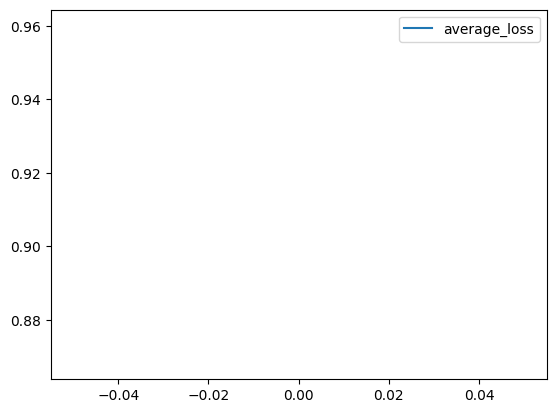

Producing 1 samples...
Model saved: 


In [ ]:
loss_list=[]
train_loop (PPD,
            train_loader_2,
            test_loader,
            optimizer=optimizer,
            print_every=batch_num*1,
            epochs=100,
            start_ep=0,
            start_step=0,
            train_unet_number=1,
            trainer=None,
            plot_unscaled=False,#if unscaled data is plotted
            max_batch_size =16,#if trainer....
            save_model=True,
            cond_scales=[1.], 
            num_samples=1,
            prefix='./output_model1/',
            need_sample=False
           )
with open('loss1.json', 'w') as json_file:  
    json.dump(loss_list, json_file)

In [17]:
with open('loss1.json', 'w') as json_file:  
    json.dump(loss_list, json_file)

first batch in test loader will be used for sampling
######################################################################################
NOW: Training epoch:  1
Loop over  414  batches (print . every  4140  steps)
.

-------------------
Time for epoch 1=14.882560388247173
-------------------
######################################################################################
NOW: Training epoch:  2
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 2=14.82820838689804
-------------------
######################################################################################
NOW: Training epoch:  3
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 3=14.894882841904957
-------------------
######################################################################################
NOW: Training epoch:  4
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 4=14.644943046569825

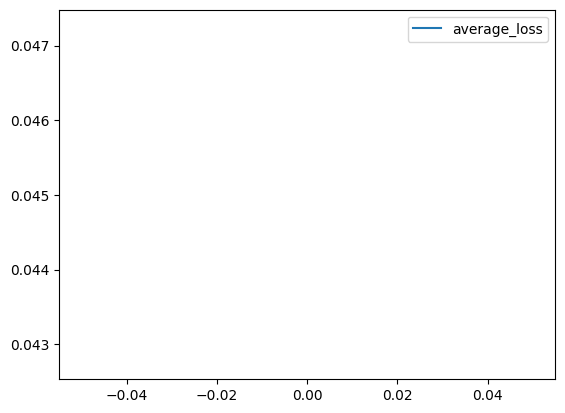

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 11=14.892005066076914
-------------------
######################################################################################
NOW: Training epoch:  12
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 12=14.833561809857686
-------------------
######################################################################################
NOW: Training epoch:  13
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 13=14.949469494819642
-------------------
######################################################################################
NOW: Training epoch:  14
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 14=14.944635514418284
-------------------
######################################################################################
NOW: Training epoch:  15
Loop over  414  batches (print . every  

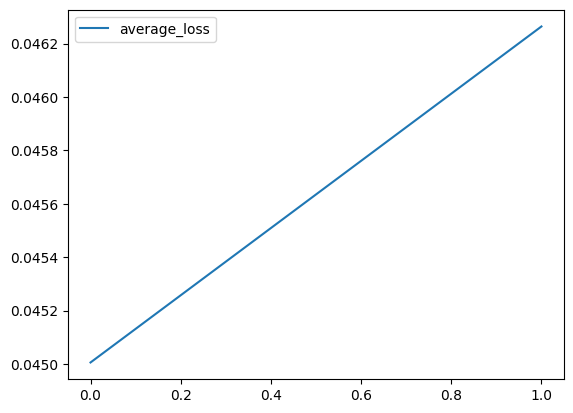

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 21=14.917702770233154
-------------------
######################################################################################
NOW: Training epoch:  22
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 22=14.95617044766744
-------------------
######################################################################################
NOW: Training epoch:  23
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 23=14.764339331785838
-------------------
######################################################################################
NOW: Training epoch:  24
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 24=14.861439327398935
-------------------
######################################################################################
NOW: Training epoch:  25
Loop over  414  batches (print . every  4

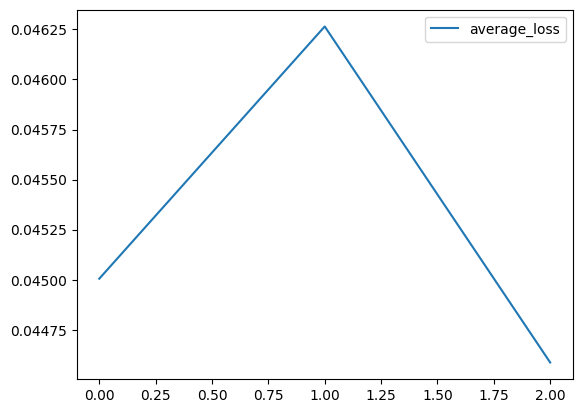

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 31=14.833709359169006
-------------------
######################################################################################
NOW: Training epoch:  32
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 32=14.817624255021412
-------------------
######################################################################################
NOW: Training epoch:  33
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 33=14.826995885372162
-------------------
######################################################################################
NOW: Training epoch:  34
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 34=15.003424457708995
-------------------
######################################################################################
NOW: Training epoch:  35
Loop over  414  batches (print . every  

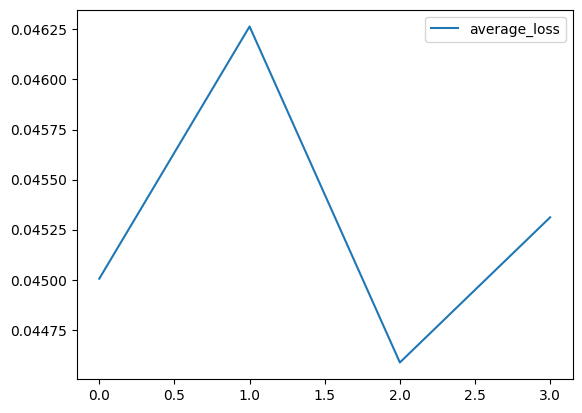

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 41=14.896815796693167
-------------------
######################################################################################
NOW: Training epoch:  42
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 42=14.99356869061788
-------------------
######################################################################################
NOW: Training epoch:  43
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 43=14.855098267396292
-------------------
######################################################################################
NOW: Training epoch:  44
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 44=14.90561902920405
-------------------
######################################################################################
NOW: Training epoch:  45
Loop over  414  batches (print . every  41

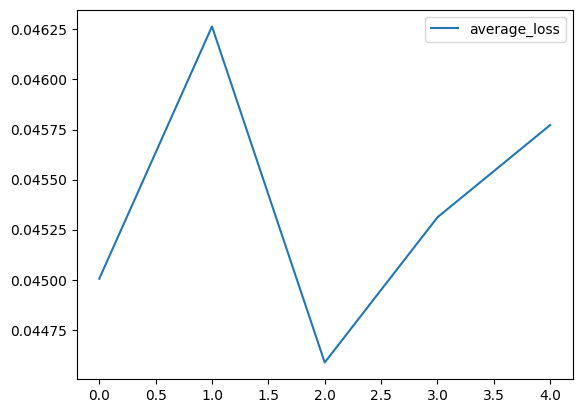

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 51=14.813805953661602
-------------------
######################################################################################
NOW: Training epoch:  52
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 52=14.730487823486328
-------------------
######################################################################################
NOW: Training epoch:  53
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 53=14.820800689856211
-------------------
######################################################################################
NOW: Training epoch:  54
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 54=14.554460167884827
-------------------
######################################################################################
NOW: Training epoch:  55
Loop over  414  batches (print . every  

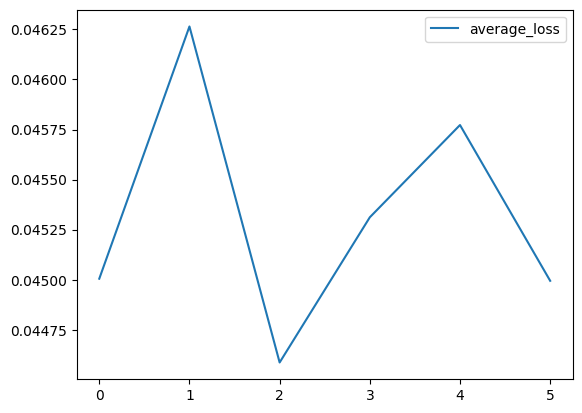

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 61=14.843526577949524
-------------------
######################################################################################
NOW: Training epoch:  62
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 62=14.932515068848927
-------------------
######################################################################################
NOW: Training epoch:  63
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 63=14.918851482868195
-------------------
######################################################################################
NOW: Training epoch:  64
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 64=14.985175347328186
-------------------
######################################################################################
NOW: Training epoch:  65
Loop over  414  batches (print . every  

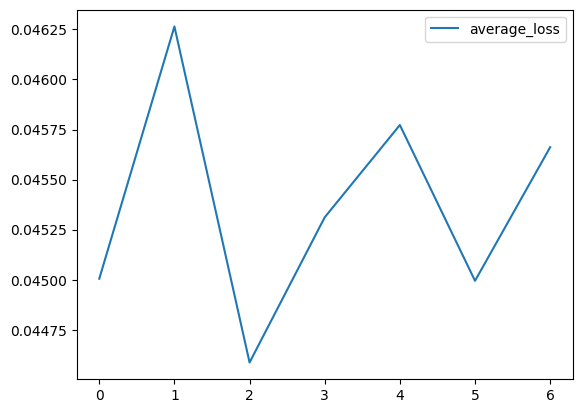

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 71=14.822170360883076
-------------------
######################################################################################
NOW: Training epoch:  72
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 72=15.096818431218464
-------------------
######################################################################################
NOW: Training epoch:  73
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 73=14.924340502421062
-------------------
######################################################################################
NOW: Training epoch:  74
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 74=14.886066579818726
-------------------
######################################################################################
NOW: Training epoch:  75
Loop over  414  batches (print . every  

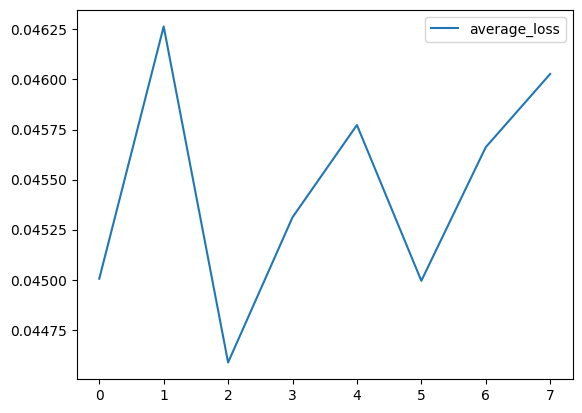

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 81=14.89785421291987
-------------------
######################################################################################
NOW: Training epoch:  82
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 82=14.790868417421978
-------------------
######################################################################################
NOW: Training epoch:  83
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 83=14.88070771296819
-------------------
######################################################################################
NOW: Training epoch:  84
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 84=14.626395320892334
-------------------
######################################################################################
NOW: Training epoch:  85
Loop over  414  batches (print . every  41

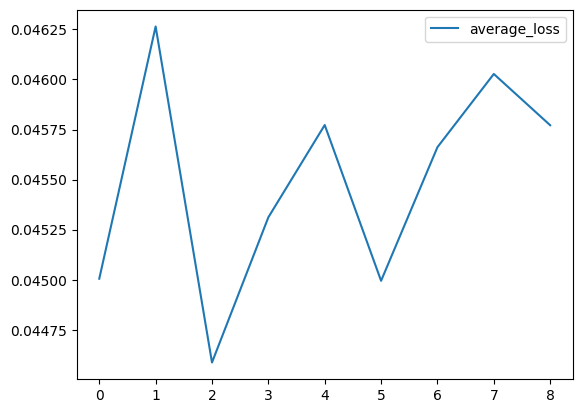

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 91=14.986731286843618
-------------------
######################################################################################
NOW: Training epoch:  92
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 92=14.804374392827352
-------------------
######################################################################################
NOW: Training epoch:  93
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 93=14.791536895434062
-------------------
######################################################################################
NOW: Training epoch:  94
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 94=14.831314758459728
-------------------
######################################################################################
NOW: Training epoch:  95
Loop over  414  batches (print . every  

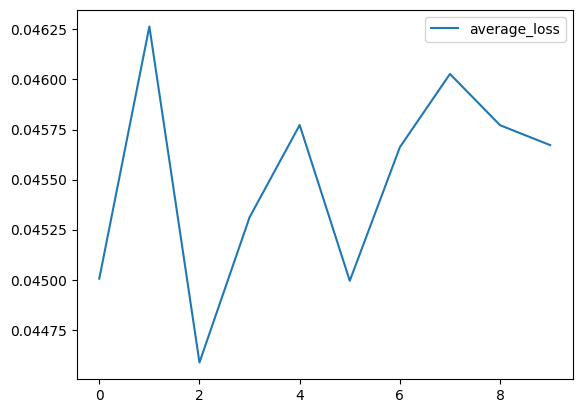

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 101=14.774065041542054
-------------------
######################################################################################
NOW: Training epoch:  102
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 102=14.971039660771687
-------------------
######################################################################################
NOW: Training epoch:  103
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 103=14.92347947359085
-------------------
######################################################################################
NOW: Training epoch:  104
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 104=14.850877670447032
-------------------
######################################################################################
NOW: Training epoch:  105
Loop over  414  batches (print . 

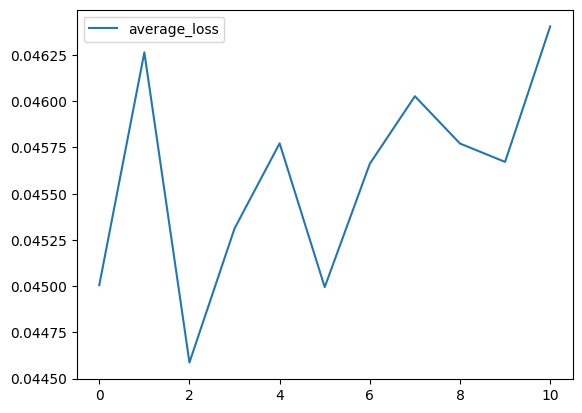

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 111=14.982555957635244
-------------------
######################################################################################
NOW: Training epoch:  112
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 112=14.654012902577717
-------------------
######################################################################################
NOW: Training epoch:  113
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 113=14.884882148106893
-------------------
######################################################################################
NOW: Training epoch:  114
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 114=14.62715490659078
-------------------
######################################################################################
NOW: Training epoch:  115
Loop over  414  batches (print . 

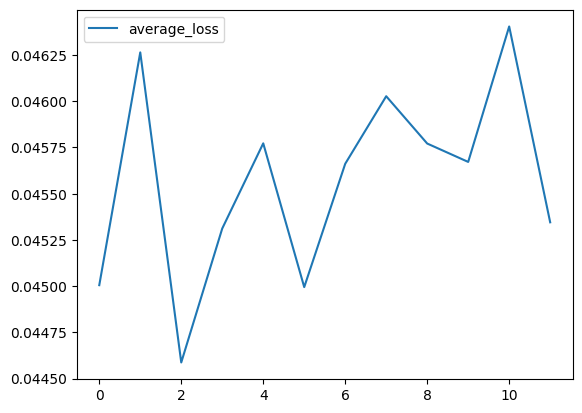

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 121=15.144390630722047
-------------------
######################################################################################
NOW: Training epoch:  122
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 122=14.729353507359823
-------------------
######################################################################################
NOW: Training epoch:  123
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 123=15.059348253409068
-------------------
######################################################################################
NOW: Training epoch:  124
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 124=14.843898411591848
-------------------
######################################################################################
NOW: Training epoch:  125
Loop over  414  batches (print .

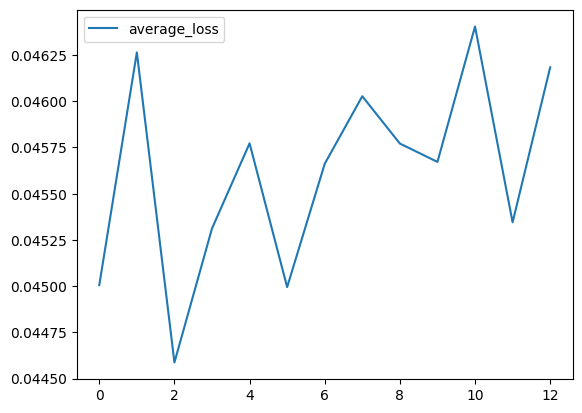

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 131=14.857966117064159
-------------------
######################################################################################
NOW: Training epoch:  132
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 132=14.559134050210316
-------------------
######################################################################################
NOW: Training epoch:  133
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 133=14.729305438200633
-------------------
######################################################################################
NOW: Training epoch:  134
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 134=14.573643624782562
-------------------
######################################################################################
NOW: Training epoch:  135
Loop over  414  batches (print .

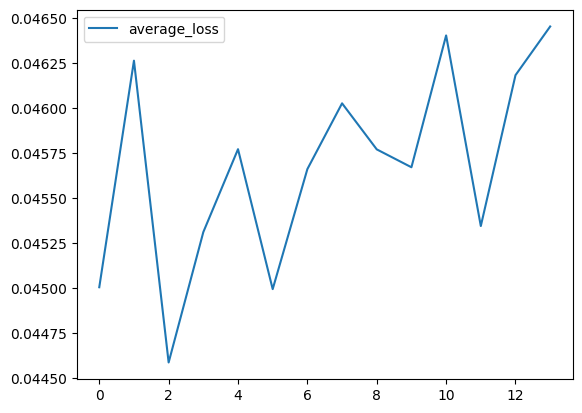

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 141=14.66913496653239
-------------------
######################################################################################
NOW: Training epoch:  142
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 142=14.635850632190705
-------------------
######################################################################################
NOW: Training epoch:  143
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 143=14.712974321842193
-------------------
######################################################################################
NOW: Training epoch:  144
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 144=14.423756273587545
-------------------
######################################################################################
NOW: Training epoch:  145
Loop over  414  batches (print . 

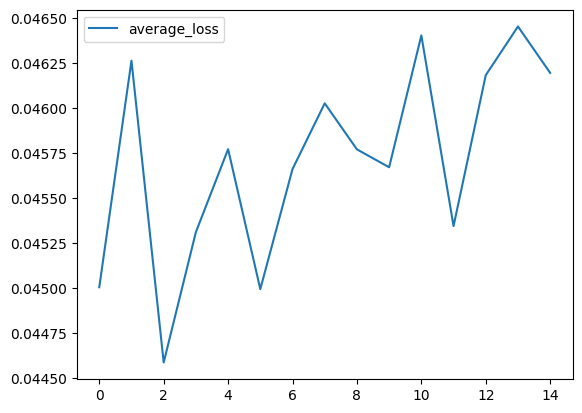

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 151=14.719880068302155
-------------------
######################################################################################
NOW: Training epoch:  152
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 152=14.614325153827668
-------------------
######################################################################################
NOW: Training epoch:  153
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 153=14.71659741004308
-------------------
######################################################################################
NOW: Training epoch:  154
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 154=14.598991401990254
-------------------
######################################################################################
NOW: Training epoch:  155
Loop over  414  batches (print . 

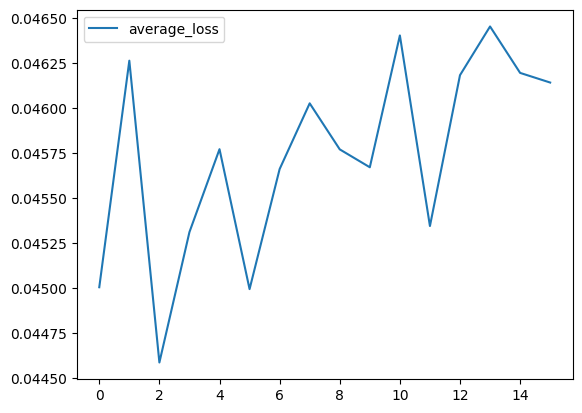

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 161=14.710170916716258
-------------------
######################################################################################
NOW: Training epoch:  162
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 162=14.786224273840586
-------------------
######################################################################################
NOW: Training epoch:  163
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 163=14.652037751674651
-------------------
######################################################################################
NOW: Training epoch:  164
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 164=14.77598453760147
-------------------
######################################################################################
NOW: Training epoch:  165
Loop over  414  batches (print . 

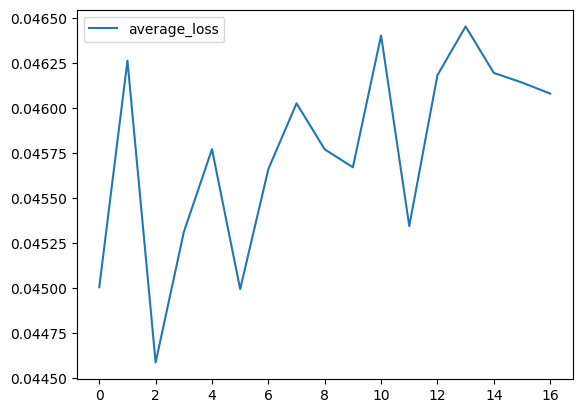

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 171=14.782726538181304
-------------------
######################################################################################
NOW: Training epoch:  172
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 172=14.625631761550903
-------------------
######################################################################################
NOW: Training epoch:  173
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 173=14.56272205511729
-------------------
######################################################################################
NOW: Training epoch:  174
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 174=14.716450377305348
-------------------
######################################################################################
NOW: Training epoch:  175
Loop over  414  batches (print . 

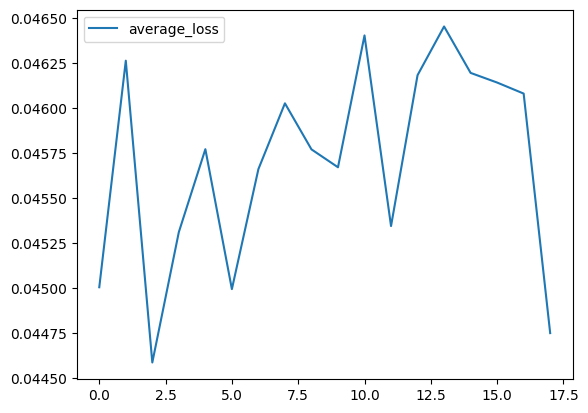

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 181=14.854846402009327
-------------------
######################################################################################
NOW: Training epoch:  182
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 182=14.929258958498638
-------------------
######################################################################################
NOW: Training epoch:  183
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 183=14.79676236708959
-------------------
######################################################################################
NOW: Training epoch:  184
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 184=14.939078032970428
-------------------
######################################################################################
NOW: Training epoch:  185
Loop over  414  batches (print . 

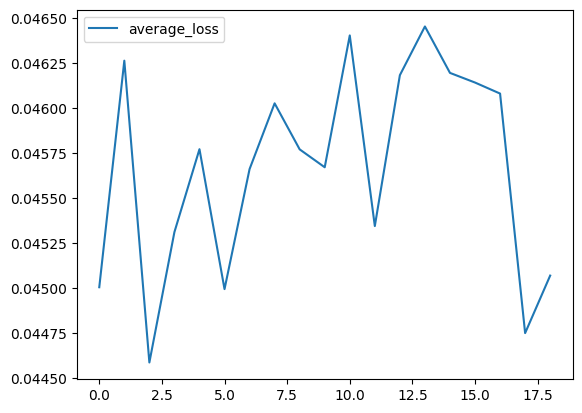

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 191=14.909708825747172
-------------------
######################################################################################
NOW: Training epoch:  192
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 192=14.840463880697886
-------------------
######################################################################################
NOW: Training epoch:  193
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 193=14.92769288221995
-------------------
######################################################################################
NOW: Training epoch:  194
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 194=15.030405453840892
-------------------
######################################################################################
NOW: Training epoch:  195
Loop over  414  batches (print . 

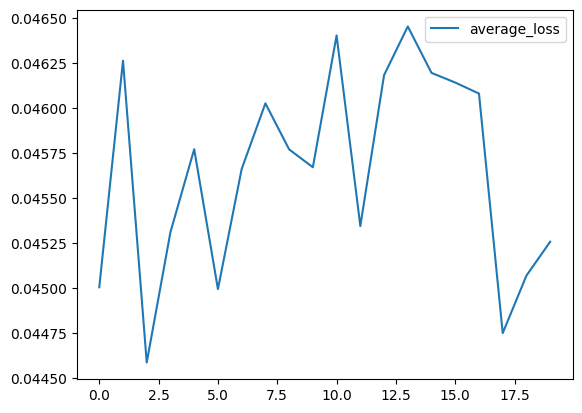

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 201=14.936395569642384
-------------------
######################################################################################
NOW: Training epoch:  202
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 202=14.891765638192494
-------------------
######################################################################################
NOW: Training epoch:  203
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 203=14.751446727911631
-------------------
######################################################################################
NOW: Training epoch:  204
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 204=14.882358622550964
-------------------
######################################################################################
NOW: Training epoch:  205
Loop over  414  batches (print .

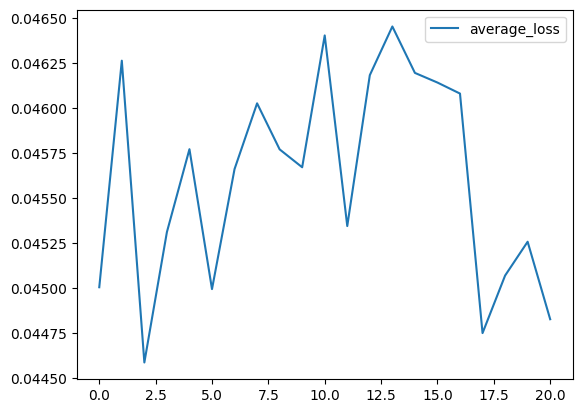

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 211=14.802966066201527
-------------------
######################################################################################
NOW: Training epoch:  212
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 212=14.84443258047104
-------------------
######################################################################################
NOW: Training epoch:  213
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 213=14.970884784062703
-------------------
######################################################################################
NOW: Training epoch:  214
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 214=14.822611828645071
-------------------
######################################################################################
NOW: Training epoch:  215
Loop over  414  batches (print . 

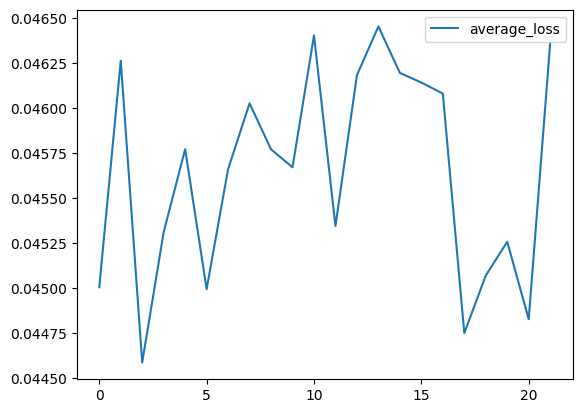

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 221=15.090362958113353
-------------------
######################################################################################
NOW: Training epoch:  222
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 222=14.882502166430156
-------------------
######################################################################################
NOW: Training epoch:  223
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 223=14.916798694928486
-------------------
######################################################################################
NOW: Training epoch:  224
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 224=15.052397414048512
-------------------
######################################################################################
NOW: Training epoch:  225
Loop over  414  batches (print .

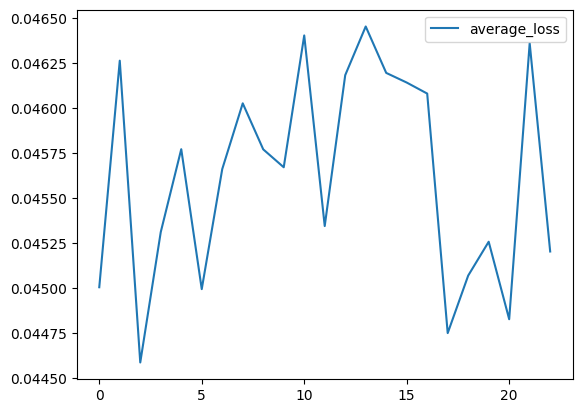

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 231=14.75963498353958
-------------------
######################################################################################
NOW: Training epoch:  232
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 232=14.811355264981588
-------------------
######################################################################################
NOW: Training epoch:  233
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 233=14.751836744944255
-------------------
######################################################################################
NOW: Training epoch:  234
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 234=14.925577803452809
-------------------
######################################################################################
NOW: Training epoch:  235
Loop over  414  batches (print . 

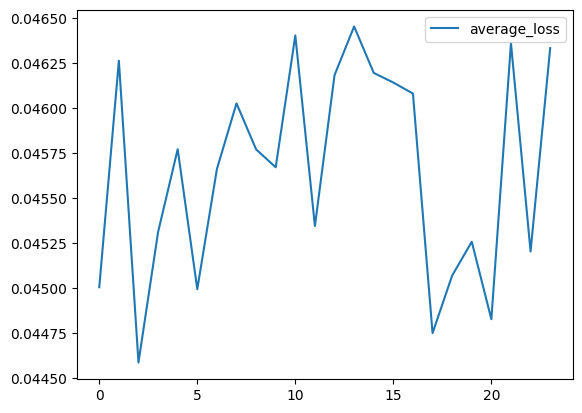

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 241=14.650054661432902
-------------------
######################################################################################
NOW: Training epoch:  242
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 242=14.777634048461914
-------------------
######################################################################################
NOW: Training epoch:  243
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 243=14.537034420172374
-------------------
######################################################################################
NOW: Training epoch:  244
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 244=14.798567907015483
-------------------
######################################################################################
NOW: Training epoch:  245
Loop over  414  batches (print .

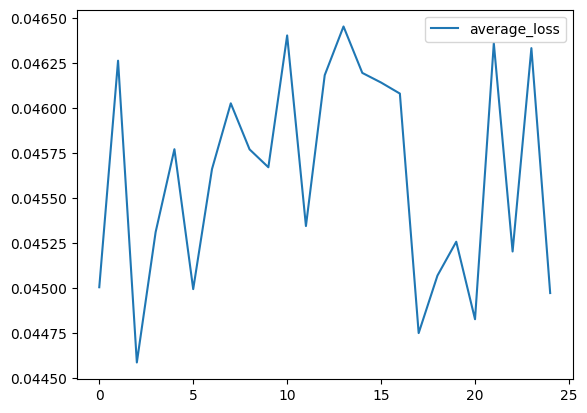

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 251=14.919557690620422
-------------------
######################################################################################
NOW: Training epoch:  252
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 252=14.771703290939332
-------------------
######################################################################################
NOW: Training epoch:  253
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 253=14.5740230123202
-------------------
######################################################################################
NOW: Training epoch:  254
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 254=14.721104896068573
-------------------
######################################################################################
NOW: Training epoch:  255
Loop over  414  batches (print . e

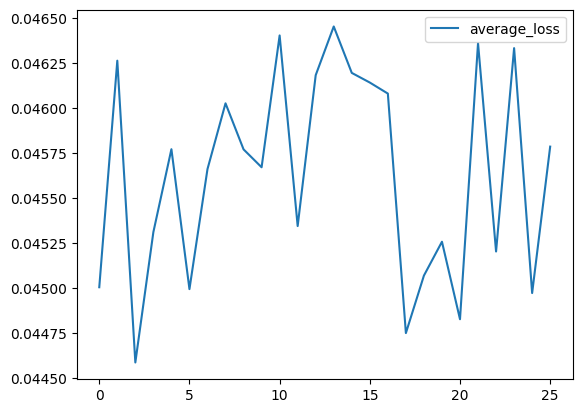

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 261=14.5470530072848
-------------------
######################################################################################
NOW: Training epoch:  262
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 262=14.872495834032694
-------------------
######################################################################################
NOW: Training epoch:  263
Loop over  414  batches (print . every  4140  steps)


-------------------
Time for epoch 263=14.746172447999319
-------------------
######################################################################################
NOW: Training epoch:  264
Loop over  414  batches (print . every  4140  steps)


In [ ]:
loss_list=[]
train_loop (PPD,
            train_loader_2,
            test_loader,
            optimizer=optimizer,
            print_every=batch_num*10,
            epochs=500,
            start_ep=0,
            start_step=0,
            train_unet_number=1,
            trainer=None,
            plot_unscaled=False,#if unscaled data is plotted
            max_batch_size =16,#if trainer....
            save_model=True,
            cond_scales=[1.], 
            num_samples=1,
            prefix='./output_model1/',
            need_sample=False
           )
with open('loss1.json', 'w') as json_file:  
    json.dump(loss_list, json_file)

first batch in test loader will be used for sampling
######################################################################################
NOW: Training epoch:  1
Loop over  193  batches (print . every  1930  steps)
.

-------------------
Time for epoch 1=9.459791827201844
-------------------
######################################################################################
NOW: Training epoch:  2
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 2=9.441139996051788
-------------------
######################################################################################
NOW: Training epoch:  3
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 3=9.136826642354329
-------------------
######################################################################################
NOW: Training epoch:  4
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 4=9.142010819911956
--

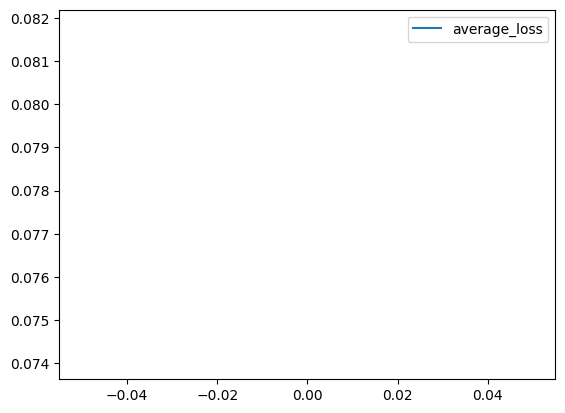

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 11=9.413047715028126
-------------------
######################################################################################
NOW: Training epoch:  12
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 12=9.300531391302744
-------------------
######################################################################################
NOW: Training epoch:  13
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 13=9.297709560394287
-------------------
######################################################################################
NOW: Training epoch:  14
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 14=9.463592183589935
-------------------
######################################################################################
NOW: Training epoch:  15
Loop over  193  batches (print . every  1930

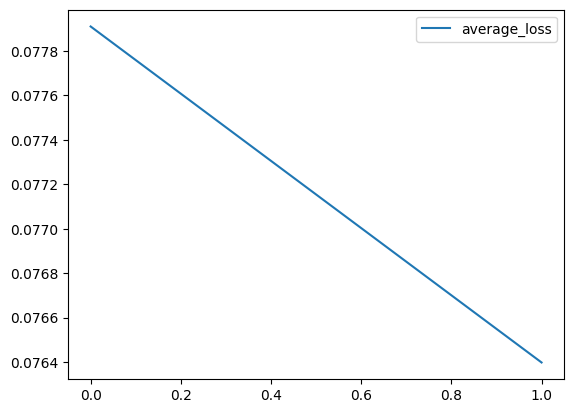

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 21=9.310536221663158
-------------------
######################################################################################
NOW: Training epoch:  22
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 22=9.257356810569764
-------------------
######################################################################################
NOW: Training epoch:  23
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 23=9.123805924256642
-------------------
######################################################################################
NOW: Training epoch:  24
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 24=9.320038155714672
-------------------
######################################################################################
NOW: Training epoch:  25
Loop over  193  batches (print . every  1930

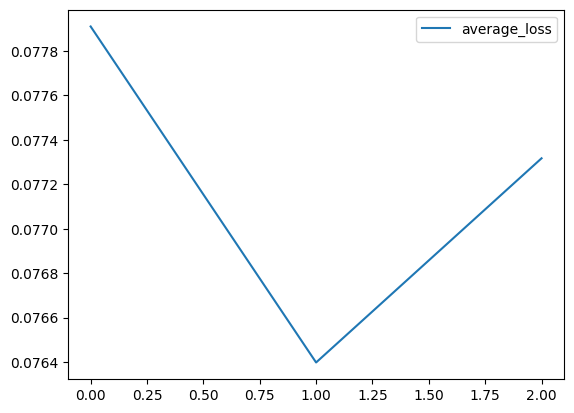

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 31=9.222685484091441
-------------------
######################################################################################
NOW: Training epoch:  32
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 32=9.30190999507904
-------------------
######################################################################################
NOW: Training epoch:  33
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 33=9.29363927046458
-------------------
######################################################################################
NOW: Training epoch:  34
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 34=9.386289978027344
-------------------
######################################################################################
NOW: Training epoch:  35
Loop over  193  batches (print . every  1930  

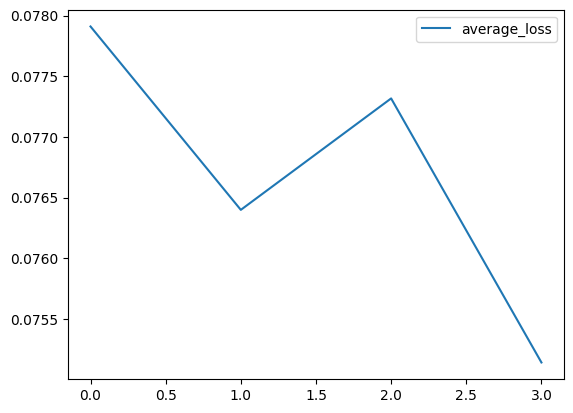

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 41=9.025472076733907
-------------------
######################################################################################
NOW: Training epoch:  42
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 42=9.290482731660207
-------------------
######################################################################################
NOW: Training epoch:  43
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 43=8.928543965021769
-------------------
######################################################################################
NOW: Training epoch:  44
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 44=9.328636332352955
-------------------
######################################################################################
NOW: Training epoch:  45
Loop over  193  batches (print . every  1930

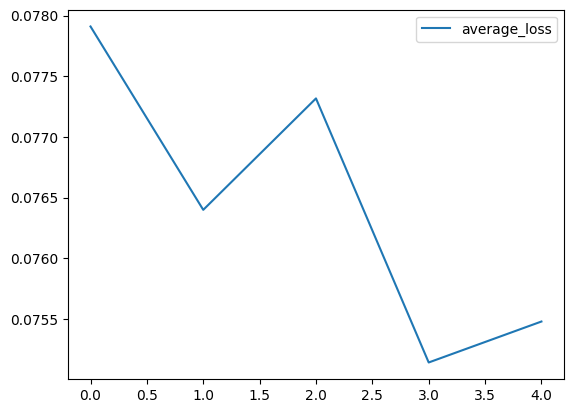

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 51=9.32988733847936
-------------------
######################################################################################
NOW: Training epoch:  52
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 52=9.52394496202469
-------------------
######################################################################################
NOW: Training epoch:  53
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 53=9.19687420129776
-------------------
######################################################################################
NOW: Training epoch:  54
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 54=9.47154719432195
-------------------
######################################################################################
NOW: Training epoch:  55
Loop over  193  batches (print . every  1930  st

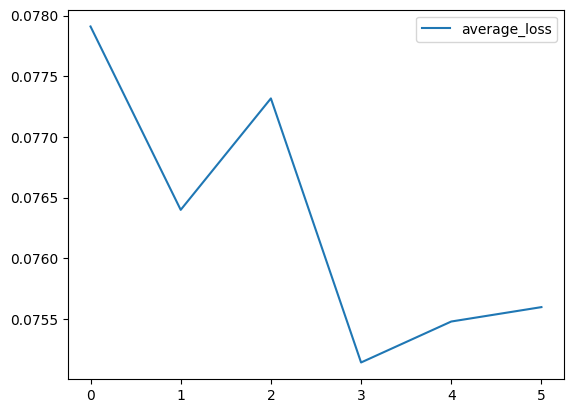

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 61=9.034152646859487
-------------------
######################################################################################
NOW: Training epoch:  62
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 62=9.057944472630819
-------------------
######################################################################################
NOW: Training epoch:  63
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 63=9.101941804091135
-------------------
######################################################################################
NOW: Training epoch:  64
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 64=9.049030923843384
-------------------
######################################################################################
NOW: Training epoch:  65
Loop over  193  batches (print . every  1930

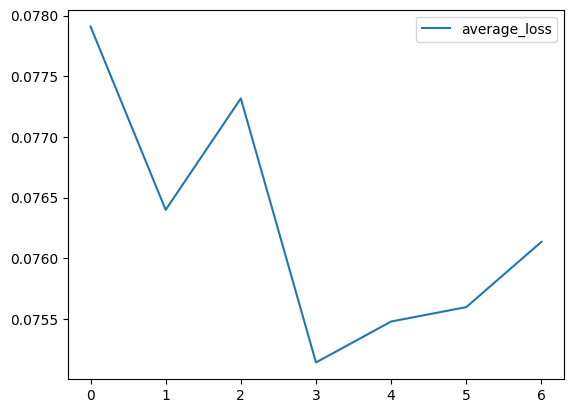

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 71=9.206769307454428
-------------------
######################################################################################
NOW: Training epoch:  72
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 72=9.505141480763752
-------------------
######################################################################################
NOW: Training epoch:  73
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 73=9.635347004731496
-------------------
######################################################################################
NOW: Training epoch:  74
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 74=9.271149265766145
-------------------
######################################################################################
NOW: Training epoch:  75
Loop over  193  batches (print . every  1930

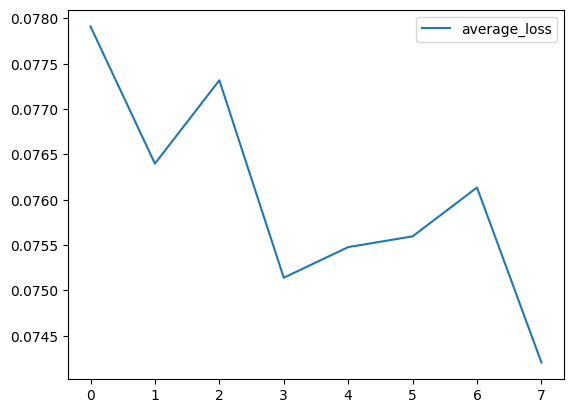

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 81=9.284924340248107
-------------------
######################################################################################
NOW: Training epoch:  82
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 82=9.330258882045745
-------------------
######################################################################################
NOW: Training epoch:  83
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 83=9.296814866860707
-------------------
######################################################################################
NOW: Training epoch:  84
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 84=9.165607420603434
-------------------
######################################################################################
NOW: Training epoch:  85
Loop over  193  batches (print . every  1930

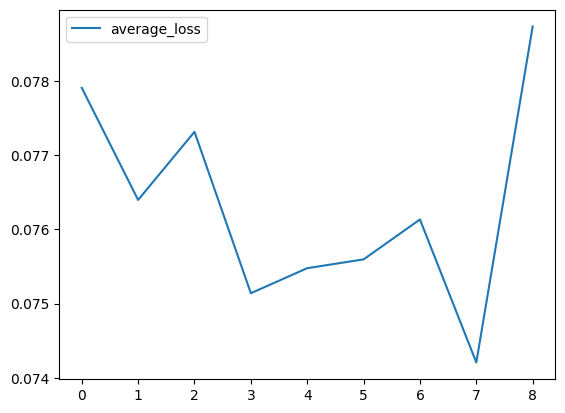

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 91=9.188005542755127
-------------------
######################################################################################
NOW: Training epoch:  92
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 92=9.329972938696544
-------------------
######################################################################################
NOW: Training epoch:  93
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 93=9.171771943569183
-------------------
######################################################################################
NOW: Training epoch:  94
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 94=9.135586675008138
-------------------
######################################################################################
NOW: Training epoch:  95
Loop over  193  batches (print . every  1930

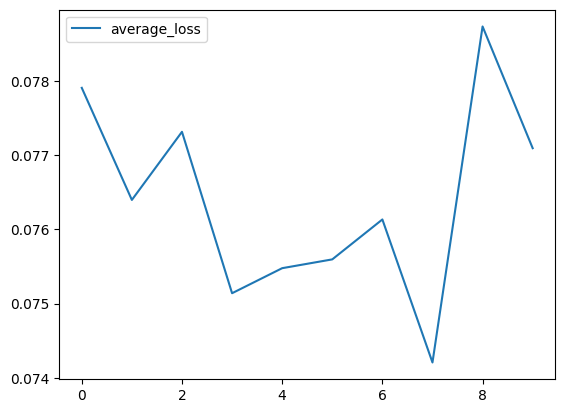

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 101=9.309221200148265
-------------------
######################################################################################
NOW: Training epoch:  102
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 102=9.2713045835495
-------------------
######################################################################################
NOW: Training epoch:  103
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 103=9.220261454582214
-------------------
######################################################################################
NOW: Training epoch:  104
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 104=9.242930058638255
-------------------
######################################################################################
NOW: Training epoch:  105
Loop over  193  batches (print . every

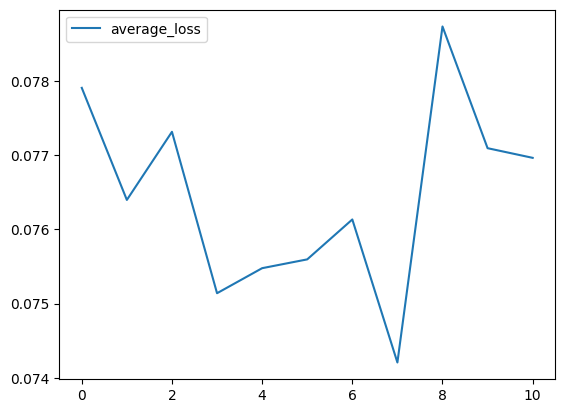

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 111=9.248540663719178
-------------------
######################################################################################
NOW: Training epoch:  112
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 112=9.038948738574982
-------------------
######################################################################################
NOW: Training epoch:  113
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 113=9.007600835959117
-------------------
######################################################################################
NOW: Training epoch:  114
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 114=9.314068734645844
-------------------
######################################################################################
NOW: Training epoch:  115
Loop over  193  batches (print . eve

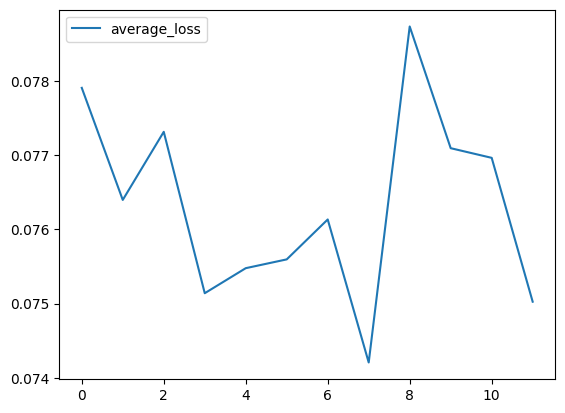

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 121=9.335994184017181
-------------------
######################################################################################
NOW: Training epoch:  122
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 122=9.134472930431366
-------------------
######################################################################################
NOW: Training epoch:  123
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 123=9.204569284121195
-------------------
######################################################################################
NOW: Training epoch:  124
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 124=9.530381910006206
-------------------
######################################################################################
NOW: Training epoch:  125
Loop over  193  batches (print . eve

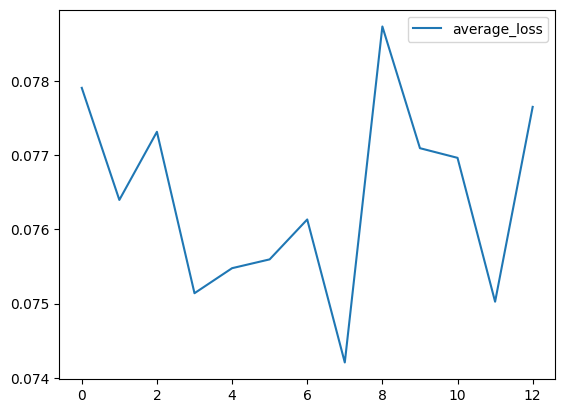

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 131=9.037122535705567
-------------------
######################################################################################
NOW: Training epoch:  132
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 132=9.36066994269689
-------------------
######################################################################################
NOW: Training epoch:  133
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 133=9.156173678239186
-------------------
######################################################################################
NOW: Training epoch:  134
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 134=9.264009312788646
-------------------
######################################################################################
NOW: Training epoch:  135
Loop over  193  batches (print . ever

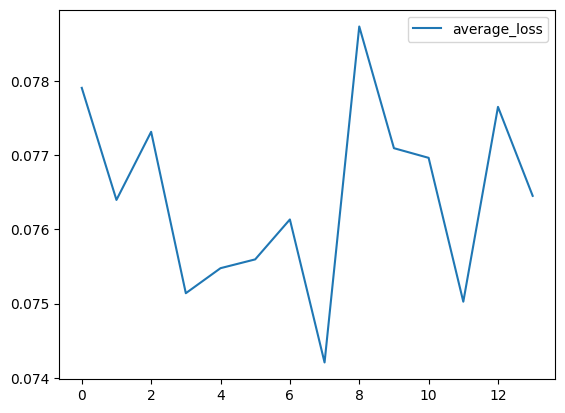

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 141=9.236580411593119
-------------------
######################################################################################
NOW: Training epoch:  142
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 142=9.208383886019389
-------------------
######################################################################################
NOW: Training epoch:  143
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 143=9.087430191040038
-------------------
######################################################################################
NOW: Training epoch:  144
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 144=9.334843198458353
-------------------
######################################################################################
NOW: Training epoch:  145
Loop over  193  batches (print . eve

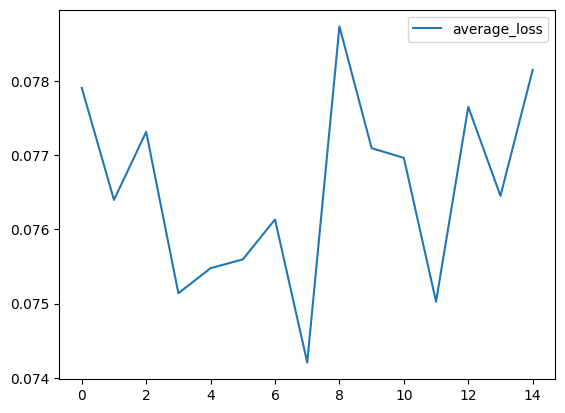

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 151=9.418762159347533
-------------------
######################################################################################
NOW: Training epoch:  152
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 152=9.523684489727021
-------------------
######################################################################################
NOW: Training epoch:  153
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 153=9.35975464185079
-------------------
######################################################################################
NOW: Training epoch:  154
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 154=9.063214635848999
-------------------
######################################################################################
NOW: Training epoch:  155
Loop over  193  batches (print . ever

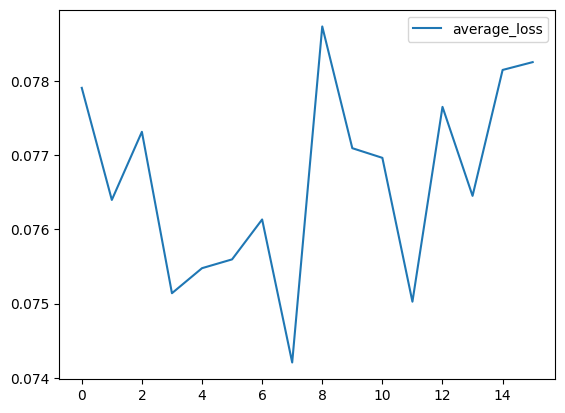

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 161=9.413037395477295
-------------------
######################################################################################
NOW: Training epoch:  162
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 162=9.473857609430949
-------------------
######################################################################################
NOW: Training epoch:  163
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 163=9.004186288515728
-------------------
######################################################################################
NOW: Training epoch:  164
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 164=9.276852536201478
-------------------
######################################################################################
NOW: Training epoch:  165
Loop over  193  batches (print . eve

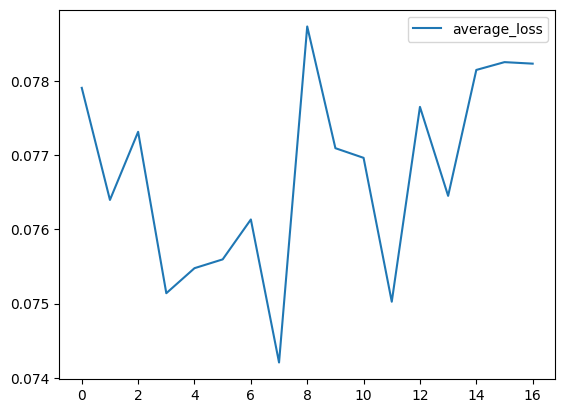

Producing 1 samples...
Model saved: 


In [ ]:
loss_list=[]
train_loop (PPD,
            train_loader_2,
            test_loader,
            optimizer=optimizer,
            print_every=batch_num*10,
            epochs=500,
            start_ep=0,
            start_step=0,
            train_unet_number=1,
            trainer=None,
            plot_unscaled=False,#if unscaled data is plotted
            max_batch_size =16,#if trainer....
            save_model=True,
            cond_scales=[1.], 
            num_samples=1,
            prefix='./output_model1/',
            need_sample=False
           )
with open('loss1.json', 'w') as json_file:  
    json.dump(loss_list, json_file)

first batch in test loader will be used for sampling
######################################################################################
NOW: Training epoch:  1
Loop over  193  batches (print . every  1930  steps)
.

-------------------
Time for epoch 1=9.25921762784322
-------------------
######################################################################################
NOW: Training epoch:  2
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 2=9.247321871916453
-------------------
######################################################################################
NOW: Training epoch:  3
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 3=9.17413508494695
-------------------
######################################################################################
NOW: Training epoch:  4
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 4=9.22579106092453
-----

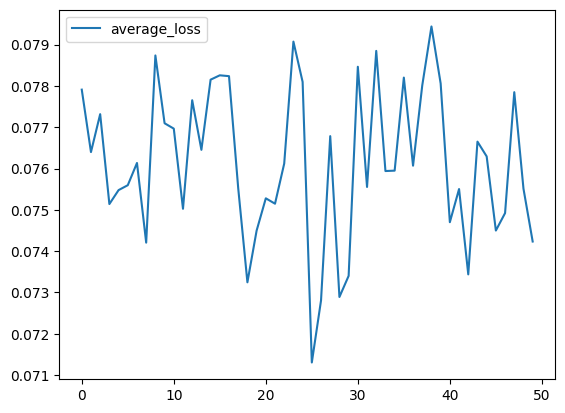

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 11=9.17896864414215
-------------------
######################################################################################
NOW: Training epoch:  12
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 12=9.204671903451283
-------------------
######################################################################################
NOW: Training epoch:  13
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 13=9.382793748378754
-------------------
######################################################################################
NOW: Training epoch:  14
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 14=9.004906582832337
-------------------
######################################################################################
NOW: Training epoch:  15
Loop over  193  batches (print . every  1930 

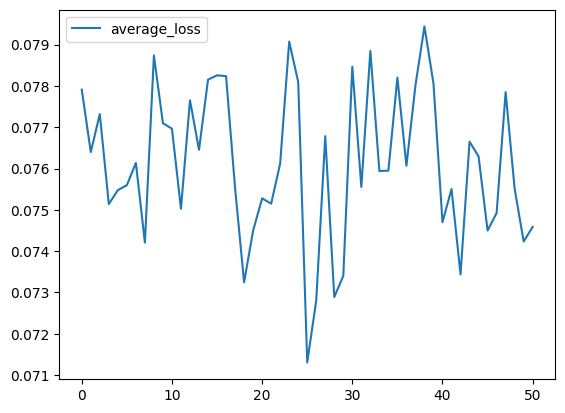

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 21=9.375469966729481
-------------------
######################################################################################
NOW: Training epoch:  22
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 22=9.298491807778676
-------------------
######################################################################################
NOW: Training epoch:  23
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 23=9.370782399177552
-------------------
######################################################################################
NOW: Training epoch:  24
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 24=9.246252918243409
-------------------
######################################################################################
NOW: Training epoch:  25
Loop over  193  batches (print . every  1930

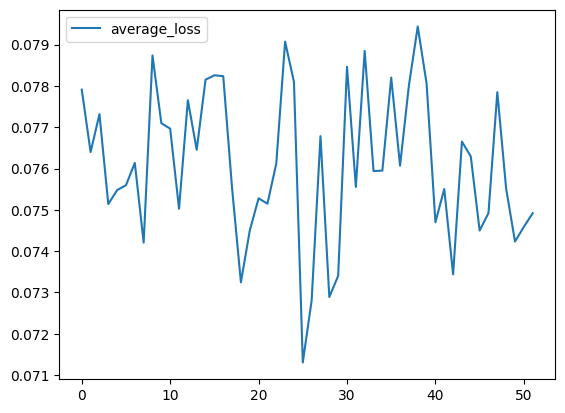

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 31=8.908981200059255
-------------------
######################################################################################
NOW: Training epoch:  32
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 32=9.244663314024608
-------------------
######################################################################################
NOW: Training epoch:  33
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 33=8.97591659228007
-------------------
######################################################################################
NOW: Training epoch:  34
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 34=9.299639554818471
-------------------
######################################################################################
NOW: Training epoch:  35
Loop over  193  batches (print . every  1930 

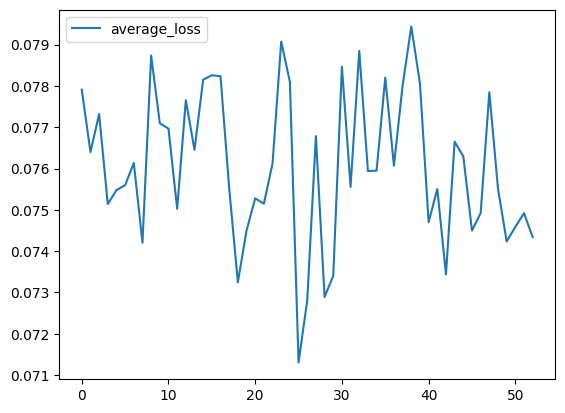

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 41=9.32508960167567
-------------------
######################################################################################
NOW: Training epoch:  42
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 42=9.43856675227483
-------------------
######################################################################################
NOW: Training epoch:  43
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 43=9.189242060979208
-------------------
######################################################################################
NOW: Training epoch:  44
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 44=9.298629407087962
-------------------
######################################################################################
NOW: Training epoch:  45
Loop over  193  batches (print . every  1930  

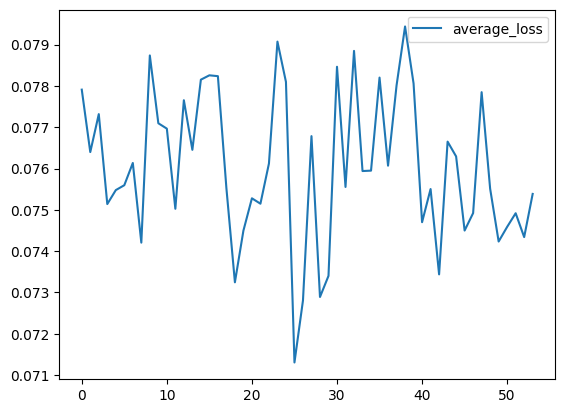

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 51=9.377182217439016
-------------------
######################################################################################
NOW: Training epoch:  52
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 52=9.156892267862956
-------------------
######################################################################################
NOW: Training epoch:  53
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 53=8.955307153860728
-------------------
######################################################################################
NOW: Training epoch:  54
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 54=9.198714168866475
-------------------
######################################################################################
NOW: Training epoch:  55
Loop over  193  batches (print . every  1930

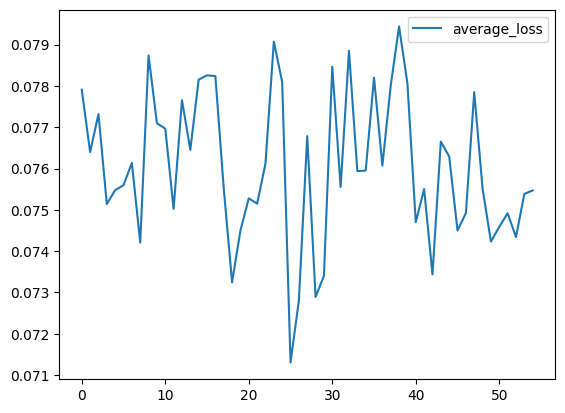

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 61=9.281755618254344
-------------------
######################################################################################
NOW: Training epoch:  62
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 62=9.172368780771892
-------------------
######################################################################################
NOW: Training epoch:  63
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 63=9.405918244520823
-------------------
######################################################################################
NOW: Training epoch:  64
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 64=9.38050155242284
-------------------
######################################################################################
NOW: Training epoch:  65
Loop over  193  batches (print . every  1930 

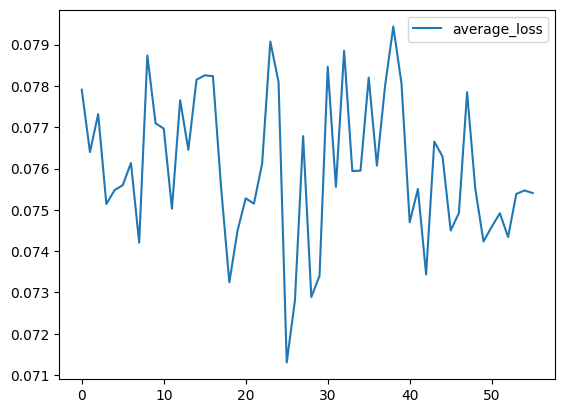

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 71=9.285028390089671
-------------------
######################################################################################
NOW: Training epoch:  72
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 72=9.434434330463409
-------------------
######################################################################################
NOW: Training epoch:  73
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 73=9.010826210180918
-------------------
######################################################################################
NOW: Training epoch:  74
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 74=9.277669048309326
-------------------
######################################################################################
NOW: Training epoch:  75
Loop over  193  batches (print . every  1930

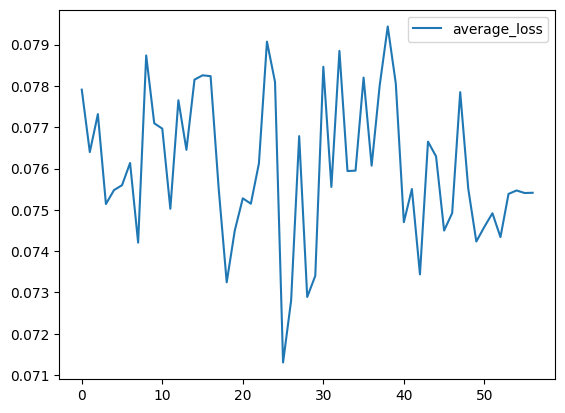

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 81=9.33819926182429
-------------------
######################################################################################
NOW: Training epoch:  82
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 82=9.188094611962637
-------------------
######################################################################################
NOW: Training epoch:  83
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 83=9.242998154958089
-------------------
######################################################################################
NOW: Training epoch:  84
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 84=9.156794476509095
-------------------
######################################################################################
NOW: Training epoch:  85
Loop over  193  batches (print . every  1930 

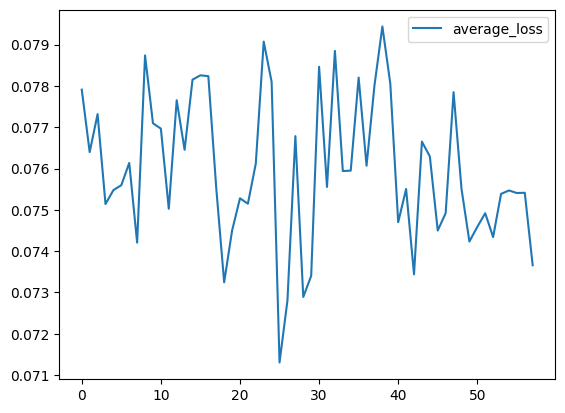

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 91=9.411574240525564
-------------------
######################################################################################
NOW: Training epoch:  92
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 92=9.0139528910319
-------------------
######################################################################################
NOW: Training epoch:  93
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 93=9.240153996149699
-------------------
######################################################################################
NOW: Training epoch:  94
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 94=9.604041469097137
-------------------
######################################################################################
NOW: Training epoch:  95
Loop over  193  batches (print . every  1930  

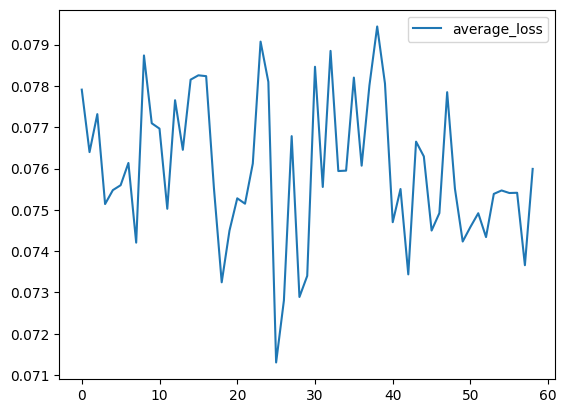

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 101=9.133647712071737
-------------------
######################################################################################
NOW: Training epoch:  102
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 102=9.092169388135273
-------------------
######################################################################################
NOW: Training epoch:  103
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 103=9.436311523119608
-------------------
######################################################################################
NOW: Training epoch:  104
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 104=9.562643011411032
-------------------
######################################################################################
NOW: Training epoch:  105
Loop over  193  batches (print . eve

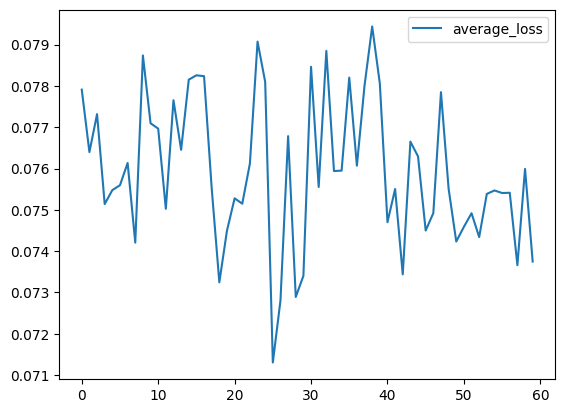

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 111=9.53356291850408
-------------------
######################################################################################
NOW: Training epoch:  112
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 112=9.27517391840617
-------------------
######################################################################################
NOW: Training epoch:  113
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 113=9.493337213993073
-------------------
######################################################################################
NOW: Training epoch:  114
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 114=9.204923915863038
-------------------
######################################################################################
NOW: Training epoch:  115
Loop over  193  batches (print . every

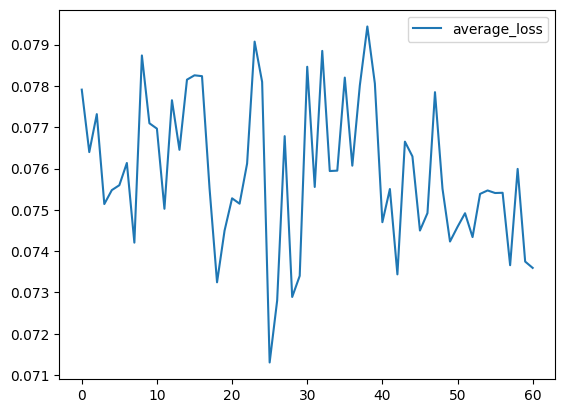

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 121=9.572290488084157
-------------------
######################################################################################
NOW: Training epoch:  122
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 122=9.457331732908886
-------------------
######################################################################################
NOW: Training epoch:  123
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 123=9.166790568828583
-------------------
######################################################################################
NOW: Training epoch:  124
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 124=9.270858760674795
-------------------
######################################################################################
NOW: Training epoch:  125
Loop over  193  batches (print . eve

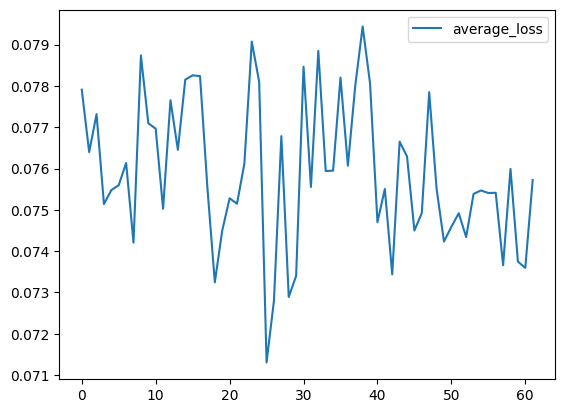

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 131=9.479869119326274
-------------------
######################################################################################
NOW: Training epoch:  132
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 132=9.179673194885254
-------------------
######################################################################################
NOW: Training epoch:  133
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 133=9.473501443862915
-------------------
######################################################################################
NOW: Training epoch:  134
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 134=9.397565456231435
-------------------
######################################################################################
NOW: Training epoch:  135
Loop over  193  batches (print . eve

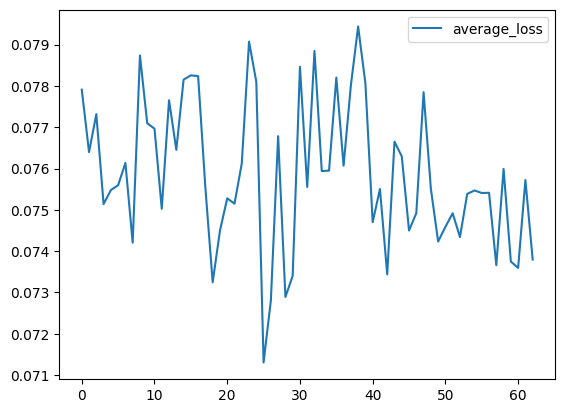

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 141=9.261582934856415
-------------------
######################################################################################
NOW: Training epoch:  142
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 142=9.071139073371887
-------------------
######################################################################################
NOW: Training epoch:  143
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 143=9.056213382879893
-------------------
######################################################################################
NOW: Training epoch:  144
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 144=9.36192722717921
-------------------
######################################################################################
NOW: Training epoch:  145
Loop over  193  batches (print . ever

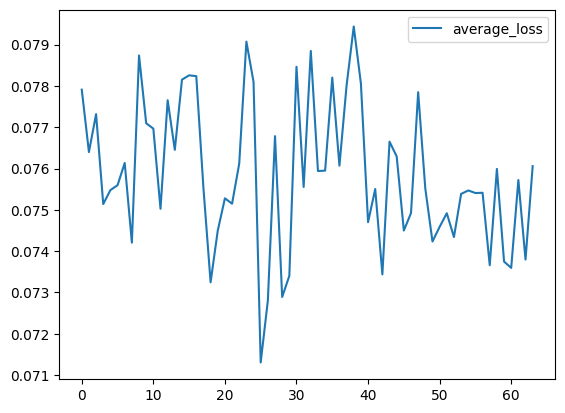

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 151=9.026016183694203
-------------------
######################################################################################
NOW: Training epoch:  152
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 152=9.274122138818106
-------------------
######################################################################################
NOW: Training epoch:  153
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 153=9.308326188723246
-------------------
######################################################################################
NOW: Training epoch:  154
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 154=9.201905127366384
-------------------
######################################################################################
NOW: Training epoch:  155
Loop over  193  batches (print . eve

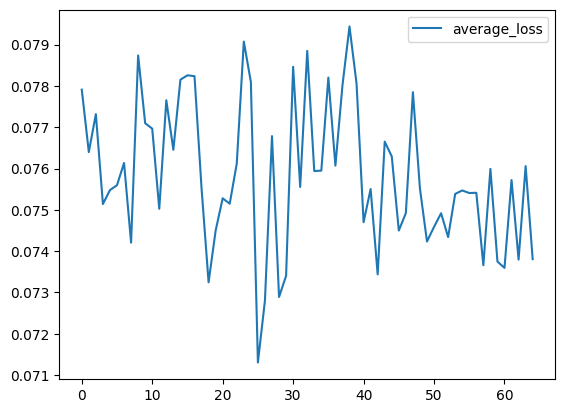

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 161=9.261844249566396
-------------------
######################################################################################
NOW: Training epoch:  162
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 162=9.235082844893137
-------------------
######################################################################################
NOW: Training epoch:  163
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 163=9.219679097334543
-------------------
######################################################################################
NOW: Training epoch:  164
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 164=9.279840862751007
-------------------
######################################################################################
NOW: Training epoch:  165
Loop over  193  batches (print . eve

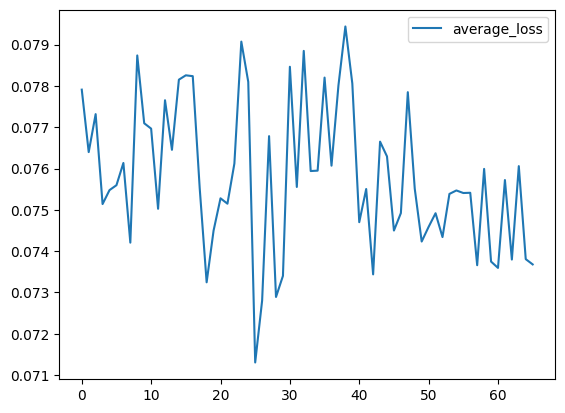

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 171=9.226184074083964
-------------------
######################################################################################
NOW: Training epoch:  172
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 172=9.04049711227417
-------------------
######################################################################################
NOW: Training epoch:  173
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 173=9.203332448005677
-------------------
######################################################################################
NOW: Training epoch:  174
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 174=9.25864464044571
-------------------
######################################################################################
NOW: Training epoch:  175
Loop over  193  batches (print . every

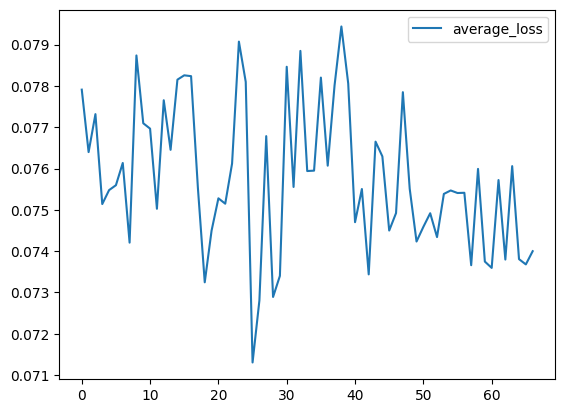

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 181=9.387683137257893
-------------------
######################################################################################
NOW: Training epoch:  182
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 182=9.348132701714833
-------------------
######################################################################################
NOW: Training epoch:  183
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 183=9.349829824765523
-------------------
######################################################################################
NOW: Training epoch:  184
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 184=9.198918322722117
-------------------
######################################################################################
NOW: Training epoch:  185
Loop over  193  batches (print . eve

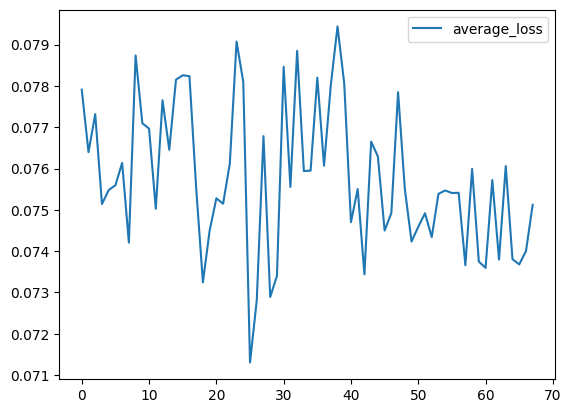

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 191=9.31852601369222
-------------------
######################################################################################
NOW: Training epoch:  192
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 192=9.110462359587352
-------------------
######################################################################################
NOW: Training epoch:  193
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 193=9.200401186943054
-------------------
######################################################################################
NOW: Training epoch:  194
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 194=9.220935583114624
-------------------
######################################################################################
NOW: Training epoch:  195
Loop over  193  batches (print . ever

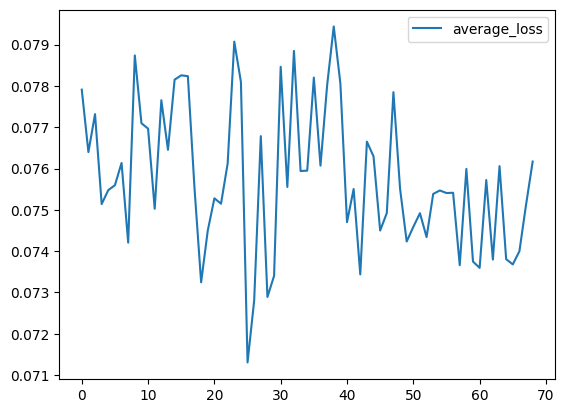

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 201=9.387183419863383
-------------------
######################################################################################
NOW: Training epoch:  202
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 202=9.220519491036733
-------------------
######################################################################################
NOW: Training epoch:  203
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 203=9.329614162445068
-------------------
######################################################################################
NOW: Training epoch:  204
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 204=9.291295063495635
-------------------
######################################################################################
NOW: Training epoch:  205
Loop over  193  batches (print . eve

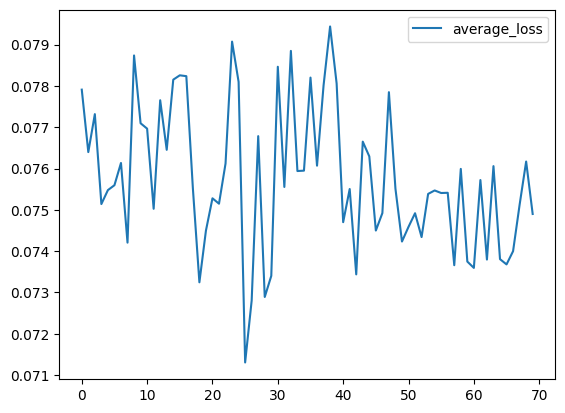

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 211=9.245038092136383
-------------------
######################################################################################
NOW: Training epoch:  212
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 212=9.16392503976822
-------------------
######################################################################################
NOW: Training epoch:  213
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 213=9.348629808425903
-------------------
######################################################################################
NOW: Training epoch:  214
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 214=9.271732501188914
-------------------
######################################################################################
NOW: Training epoch:  215
Loop over  193  batches (print . ever

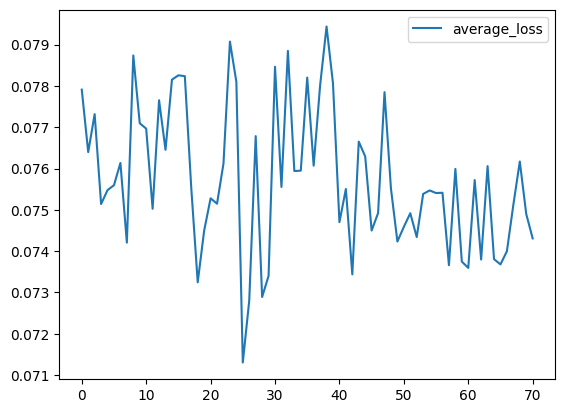

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 221=9.33267103433609
-------------------
######################################################################################
NOW: Training epoch:  222
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 222=9.03785843849182
-------------------
######################################################################################
NOW: Training epoch:  223
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 223=9.216383063793183
-------------------
######################################################################################
NOW: Training epoch:  224
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 224=9.48760621547699
-------------------
######################################################################################
NOW: Training epoch:  225
Loop over  193  batches (print . every 

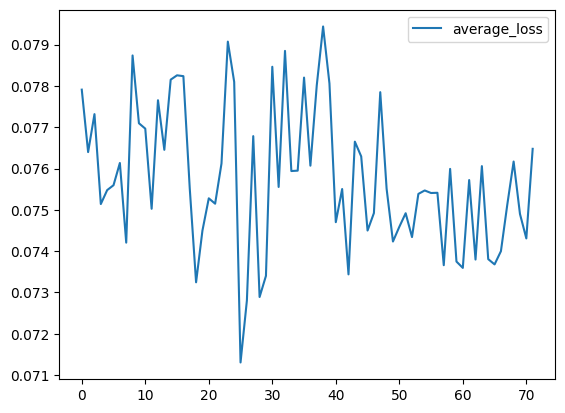

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 231=9.425982554753622
-------------------
######################################################################################
NOW: Training epoch:  232
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 232=9.184141063690186
-------------------
######################################################################################
NOW: Training epoch:  233
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 233=9.22024137576421
-------------------
######################################################################################
NOW: Training epoch:  234
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 234=9.059706489245096
-------------------
######################################################################################
NOW: Training epoch:  235
Loop over  193  batches (print . ever

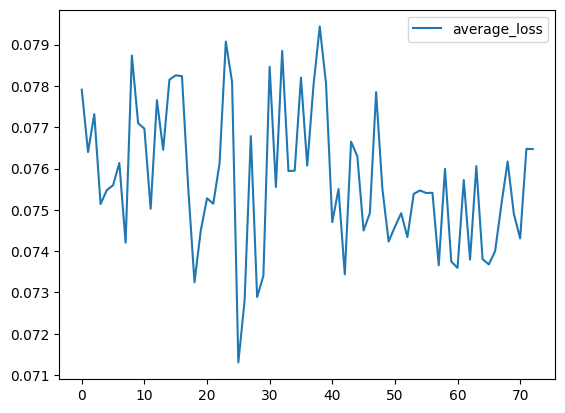

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 241=9.062230734030406
-------------------
######################################################################################
NOW: Training epoch:  242
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 242=9.400910051663717
-------------------
######################################################################################
NOW: Training epoch:  243
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 243=9.145788987477621
-------------------
######################################################################################
NOW: Training epoch:  244
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 244=9.239979759852092
-------------------
######################################################################################
NOW: Training epoch:  245
Loop over  193  batches (print . eve

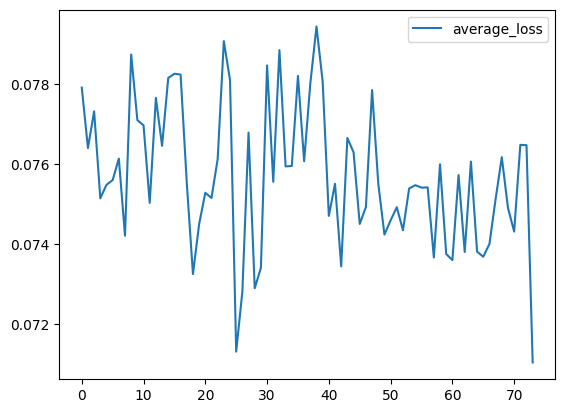

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 251=9.255181475480397
-------------------
######################################################################################
NOW: Training epoch:  252
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 252=9.455778749783834
-------------------
######################################################################################
NOW: Training epoch:  253
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 253=9.183182466030122
-------------------
######################################################################################
NOW: Training epoch:  254
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 254=9.223298827807108
-------------------
######################################################################################
NOW: Training epoch:  255
Loop over  193  batches (print . eve

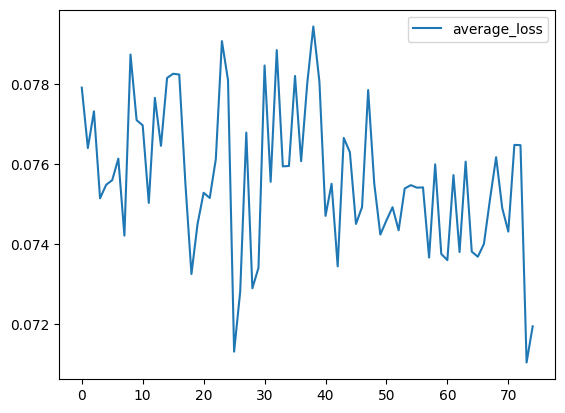

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 261=9.259140519301097
-------------------
######################################################################################
NOW: Training epoch:  262
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 262=9.40311454931895
-------------------
######################################################################################
NOW: Training epoch:  263
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 263=9.097007449467977
-------------------
######################################################################################
NOW: Training epoch:  264
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 264=9.184417847792307
-------------------
######################################################################################
NOW: Training epoch:  265
Loop over  193  batches (print . ever

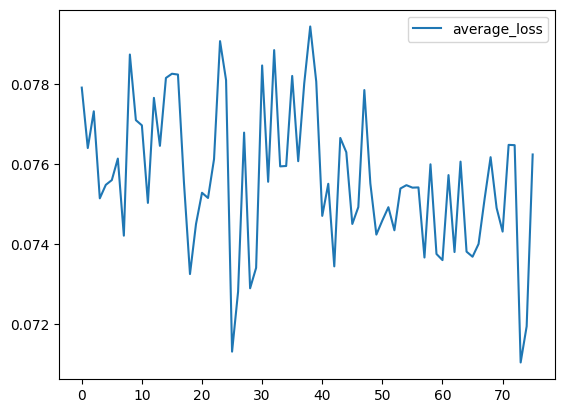

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 271=9.147966341177623
-------------------
######################################################################################
NOW: Training epoch:  272
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 272=9.240500609079996
-------------------
######################################################################################
NOW: Training epoch:  273
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 273=9.289796046415965
-------------------
######################################################################################
NOW: Training epoch:  274
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 274=9.45213007926941
-------------------
######################################################################################
NOW: Training epoch:  275
Loop over  193  batches (print . ever

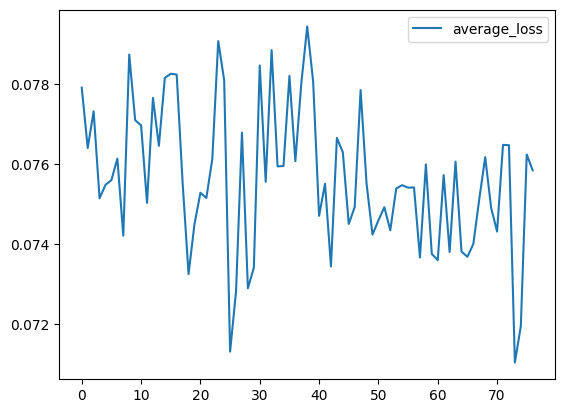

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 281=9.354973344008128
-------------------
######################################################################################
NOW: Training epoch:  282
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 282=9.206195481618245
-------------------
######################################################################################
NOW: Training epoch:  283
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 283=9.210711248715718
-------------------
######################################################################################
NOW: Training epoch:  284
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 284=9.207026429971059
-------------------
######################################################################################
NOW: Training epoch:  285
Loop over  193  batches (print . eve

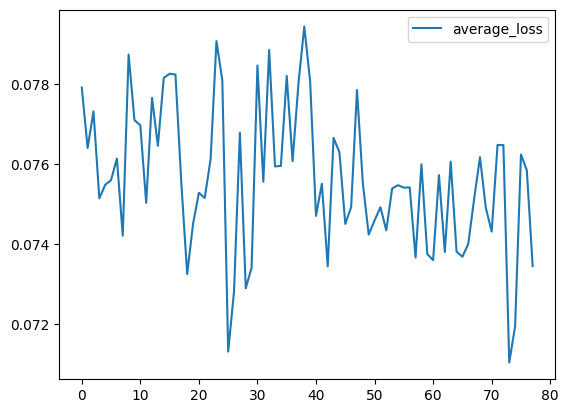

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 291=9.329742781321208
-------------------
######################################################################################
NOW: Training epoch:  292
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 292=9.034987918535869
-------------------
######################################################################################
NOW: Training epoch:  293
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 293=9.361262504259745
-------------------
######################################################################################
NOW: Training epoch:  294
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 294=9.311013317108154
-------------------
######################################################################################
NOW: Training epoch:  295
Loop over  193  batches (print . eve

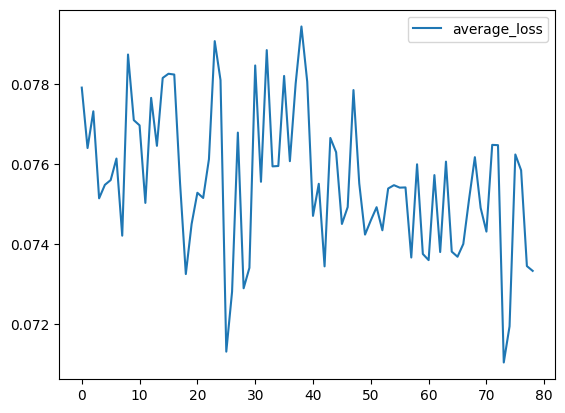

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 301=9.456288468837737
-------------------
######################################################################################
NOW: Training epoch:  302
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 302=9.256941560904185
-------------------
######################################################################################
NOW: Training epoch:  303
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 303=9.324436899026235
-------------------
######################################################################################
NOW: Training epoch:  304
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 304=9.167654538154602
-------------------
######################################################################################
NOW: Training epoch:  305
Loop over  193  batches (print . eve

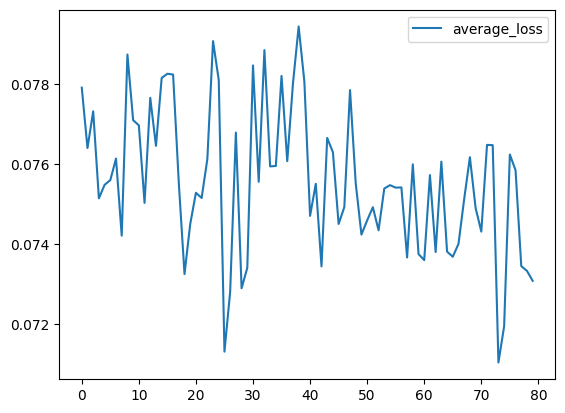

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 311=9.471521230538686
-------------------
######################################################################################
NOW: Training epoch:  312
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 312=9.214540243148804
-------------------
######################################################################################
NOW: Training epoch:  313
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 313=8.989064129193624
-------------------
######################################################################################
NOW: Training epoch:  314
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 314=9.251325221856435
-------------------
######################################################################################
NOW: Training epoch:  315
Loop over  193  batches (print . eve

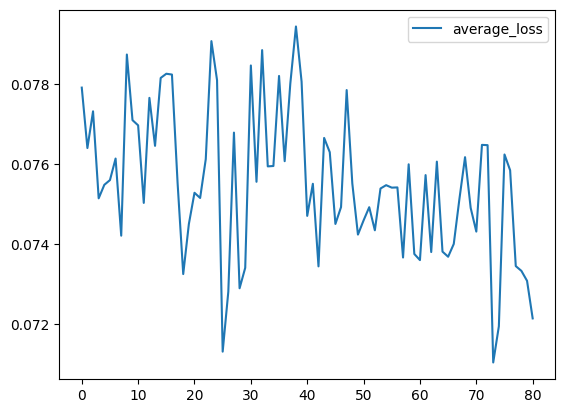

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 321=9.469464337825775
-------------------
######################################################################################
NOW: Training epoch:  322
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 322=9.261230178674062
-------------------
######################################################################################
NOW: Training epoch:  323
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 323=9.225521906216938
-------------------
######################################################################################
NOW: Training epoch:  324
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 324=9.154617138703664
-------------------
######################################################################################
NOW: Training epoch:  325
Loop over  193  batches (print . eve

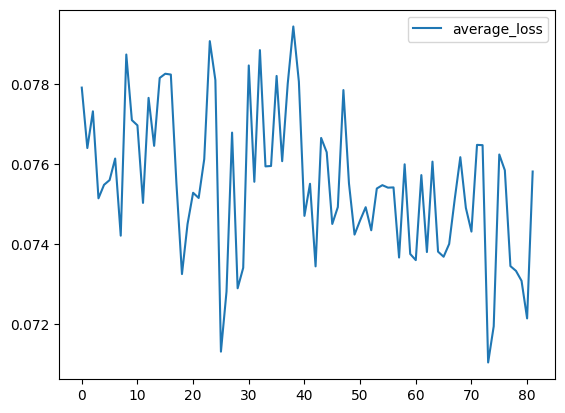

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 331=9.355061546961467
-------------------
######################################################################################
NOW: Training epoch:  332
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 332=9.3446670850118
-------------------
######################################################################################
NOW: Training epoch:  333
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 333=9.193181065718333
-------------------
######################################################################################
NOW: Training epoch:  334
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 334=9.33447539806366
-------------------
######################################################################################
NOW: Training epoch:  335
Loop over  193  batches (print . every 

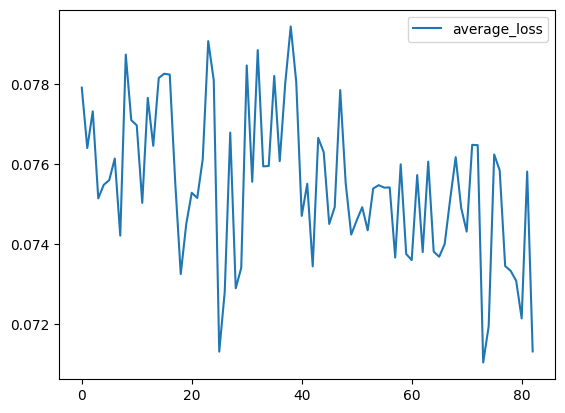

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 341=9.282895092169444
-------------------
######################################################################################
NOW: Training epoch:  342
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 342=9.189221994082134
-------------------
######################################################################################
NOW: Training epoch:  343
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 343=9.007490122318268
-------------------
######################################################################################
NOW: Training epoch:  344
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 344=9.11733615398407
-------------------
######################################################################################
NOW: Training epoch:  345
Loop over  193  batches (print . ever

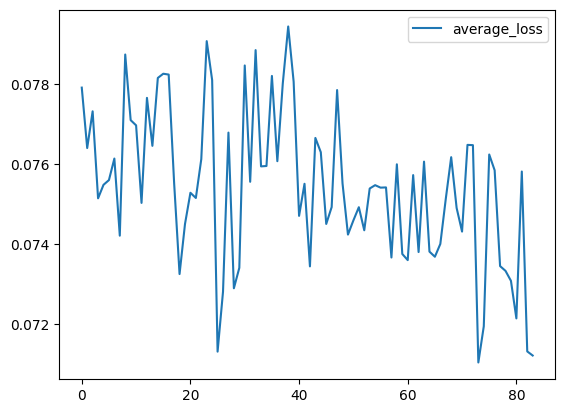

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 351=9.322749487559001
-------------------
######################################################################################
NOW: Training epoch:  352
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 352=9.208682990074157
-------------------
######################################################################################
NOW: Training epoch:  353
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 353=9.206734470526378
-------------------
######################################################################################
NOW: Training epoch:  354
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 354=9.536458313465118
-------------------
######################################################################################
NOW: Training epoch:  355
Loop over  193  batches (print . eve

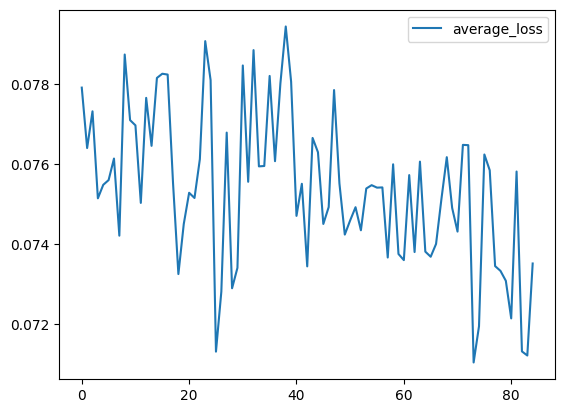

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 361=9.408435861269632
-------------------
######################################################################################
NOW: Training epoch:  362
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 362=9.302094844977061
-------------------
######################################################################################
NOW: Training epoch:  363
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 363=9.244558354218801
-------------------
######################################################################################
NOW: Training epoch:  364
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 364=9.321335915724436
-------------------
######################################################################################
NOW: Training epoch:  365
Loop over  193  batches (print . eve

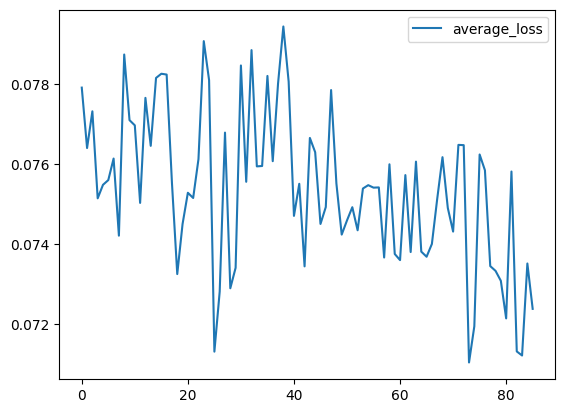

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 371=9.235420906543732
-------------------
######################################################################################
NOW: Training epoch:  372
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 372=9.278111402193705
-------------------
######################################################################################
NOW: Training epoch:  373
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 373=8.970841936270396
-------------------
######################################################################################
NOW: Training epoch:  374
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 374=9.081925984223684
-------------------
######################################################################################
NOW: Training epoch:  375
Loop over  193  batches (print . eve

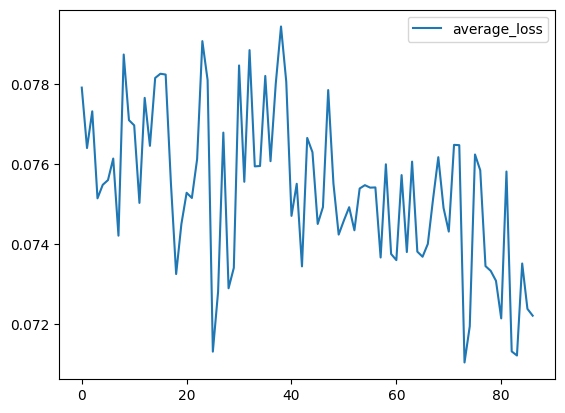

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 381=9.14629940589269
-------------------
######################################################################################
NOW: Training epoch:  382
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 382=9.282000517845153
-------------------
######################################################################################
NOW: Training epoch:  383
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 383=9.4819428841273
-------------------
######################################################################################
NOW: Training epoch:  384
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 384=9.570878839492797
-------------------
######################################################################################
NOW: Training epoch:  385
Loop over  193  batches (print . every 

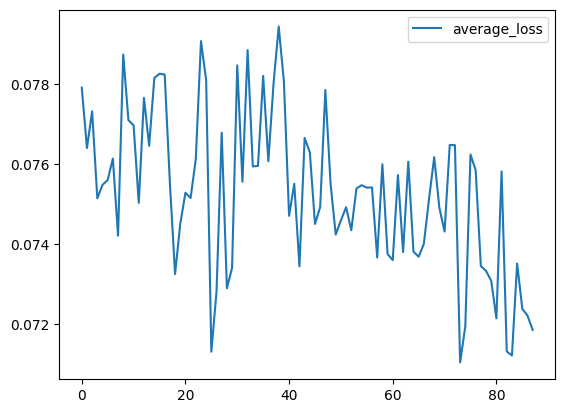

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 391=9.290704111258188
-------------------
######################################################################################
NOW: Training epoch:  392
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 392=9.044336712360382
-------------------
######################################################################################
NOW: Training epoch:  393
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 393=9.158050135771434
-------------------
######################################################################################
NOW: Training epoch:  394
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 394=9.368747953573862
-------------------
######################################################################################
NOW: Training epoch:  395
Loop over  193  batches (print . eve

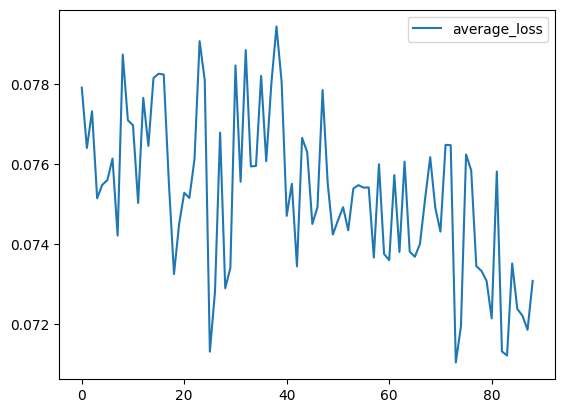

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 401=9.0512762149175
-------------------
######################################################################################
NOW: Training epoch:  402
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 402=9.169699931144715
-------------------
######################################################################################
NOW: Training epoch:  403
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 403=9.169010905424754
-------------------
######################################################################################
NOW: Training epoch:  404
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 404=9.286171221733094
-------------------
######################################################################################
NOW: Training epoch:  405
Loop over  193  batches (print . every

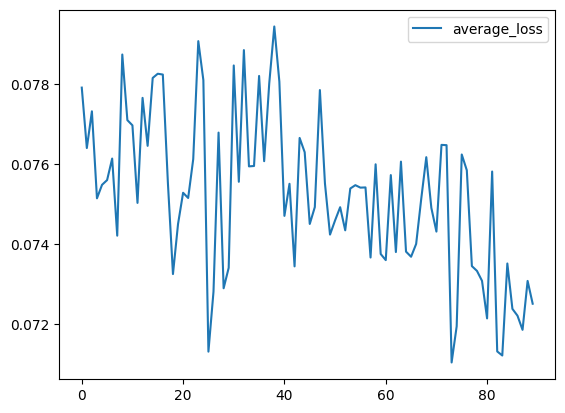

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 411=9.341066102186838
-------------------
######################################################################################
NOW: Training epoch:  412
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 412=9.084620269139608
-------------------
######################################################################################
NOW: Training epoch:  413
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 413=9.224294543266296
-------------------
######################################################################################
NOW: Training epoch:  414
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 414=9.407340133190155
-------------------
######################################################################################
NOW: Training epoch:  415
Loop over  193  batches (print . eve

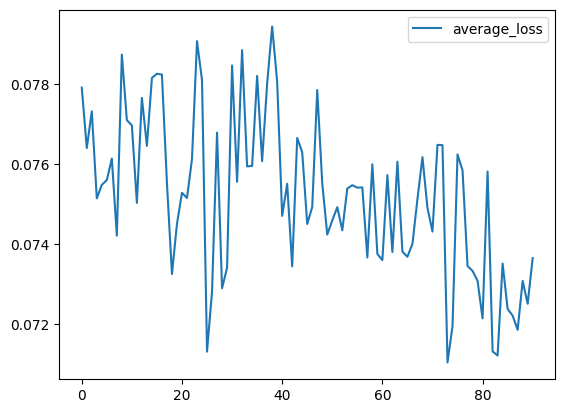

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 421=9.237788367271424
-------------------
######################################################################################
NOW: Training epoch:  422
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 422=9.060881892840067
-------------------
######################################################################################
NOW: Training epoch:  423
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 423=9.1135072072347
-------------------
######################################################################################
NOW: Training epoch:  424
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 424=9.316998048623402
-------------------
######################################################################################
NOW: Training epoch:  425
Loop over  193  batches (print . every

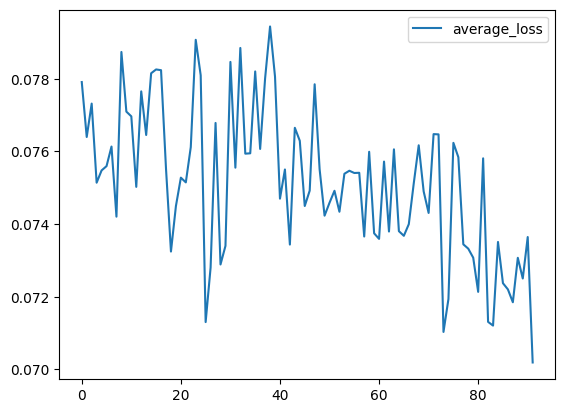

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 431=9.177788507938384
-------------------
######################################################################################
NOW: Training epoch:  432
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 432=9.352597312132518
-------------------
######################################################################################
NOW: Training epoch:  433
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 433=9.272552080949147
-------------------
######################################################################################
NOW: Training epoch:  434
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 434=9.044584234555563
-------------------
######################################################################################
NOW: Training epoch:  435
Loop over  193  batches (print . eve

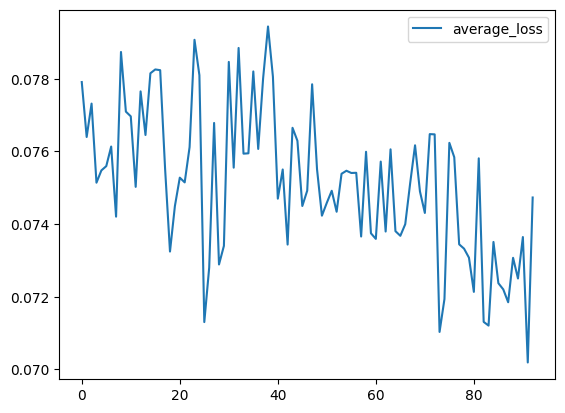

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 441=9.268339459101359
-------------------
######################################################################################
NOW: Training epoch:  442
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 442=9.16694993575414
-------------------
######################################################################################
NOW: Training epoch:  443
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 443=9.22927608092626
-------------------
######################################################################################
NOW: Training epoch:  444
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 444=9.374498987197876
-------------------
######################################################################################
NOW: Training epoch:  445
Loop over  193  batches (print . every

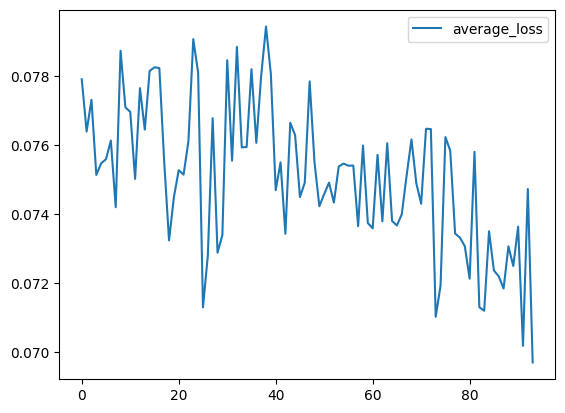

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 451=9.377576224009196
-------------------
######################################################################################
NOW: Training epoch:  452
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 452=9.15672865708669
-------------------
######################################################################################
NOW: Training epoch:  453
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 453=9.258452701568604
-------------------
######################################################################################
NOW: Training epoch:  454
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 454=9.278075901667277
-------------------
######################################################################################
NOW: Training epoch:  455
Loop over  193  batches (print . ever

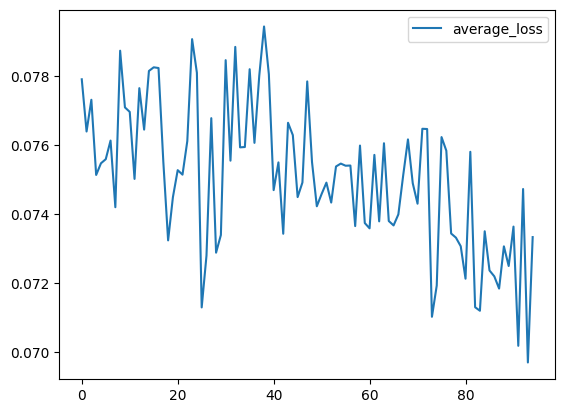

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 461=9.163321991761526
-------------------
######################################################################################
NOW: Training epoch:  462
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 462=9.261045670509338
-------------------
######################################################################################
NOW: Training epoch:  463
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 463=9.228090739250183
-------------------
######################################################################################
NOW: Training epoch:  464
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 464=9.403564234574636
-------------------
######################################################################################
NOW: Training epoch:  465
Loop over  193  batches (print . eve

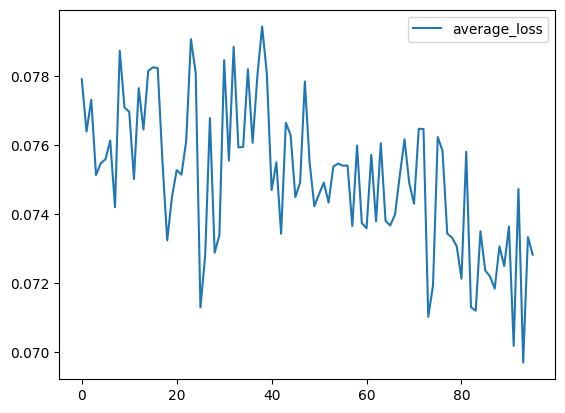

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 471=9.160818779468537
-------------------
######################################################################################
NOW: Training epoch:  472
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 472=9.425398421287536
-------------------
######################################################################################
NOW: Training epoch:  473
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 473=9.278295528888702
-------------------
######################################################################################
NOW: Training epoch:  474
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 474=9.204948238531749
-------------------
######################################################################################
NOW: Training epoch:  475
Loop over  193  batches (print . eve

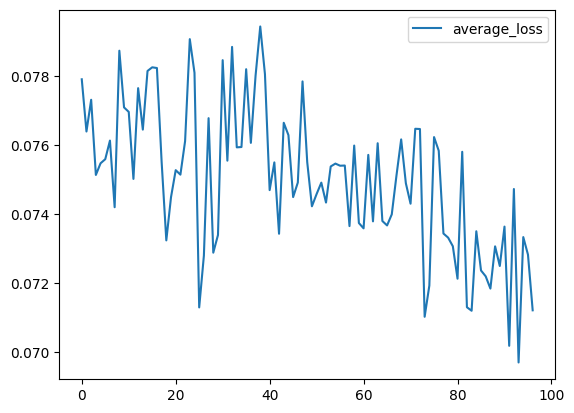

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 481=9.445145324865978
-------------------
######################################################################################
NOW: Training epoch:  482
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 482=9.276167702674865
-------------------
######################################################################################
NOW: Training epoch:  483
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 483=9.152831538518269
-------------------
######################################################################################
NOW: Training epoch:  484
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 484=9.354244979222615
-------------------
######################################################################################
NOW: Training epoch:  485
Loop over  193  batches (print . eve

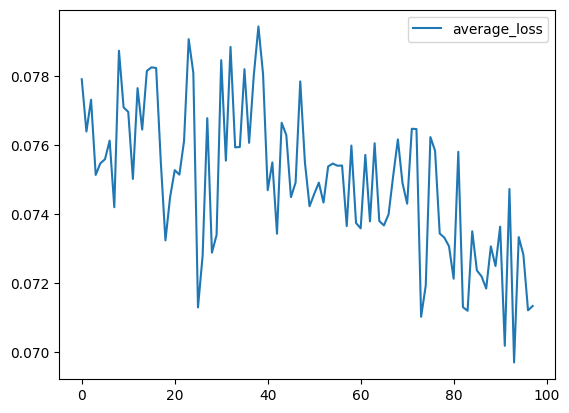

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 491=9.379860281944275
-------------------
######################################################################################
NOW: Training epoch:  492
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 492=9.406165917714437
-------------------
######################################################################################
NOW: Training epoch:  493
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 493=9.280477329095204
-------------------
######################################################################################
NOW: Training epoch:  494
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 494=9.26160279115041
-------------------
######################################################################################
NOW: Training epoch:  495
Loop over  193  batches (print . ever

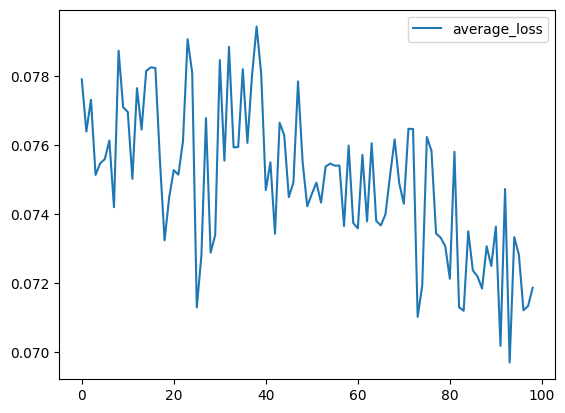

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 501=9.570164561271667
-------------------
######################################################################################
NOW: Training epoch:  502
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 502=9.296300144990285
-------------------
######################################################################################
NOW: Training epoch:  503
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 503=9.13140379190445
-------------------
######################################################################################
NOW: Training epoch:  504
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 504=9.220162387688955
-------------------
######################################################################################
NOW: Training epoch:  505
Loop over  193  batches (print . ever

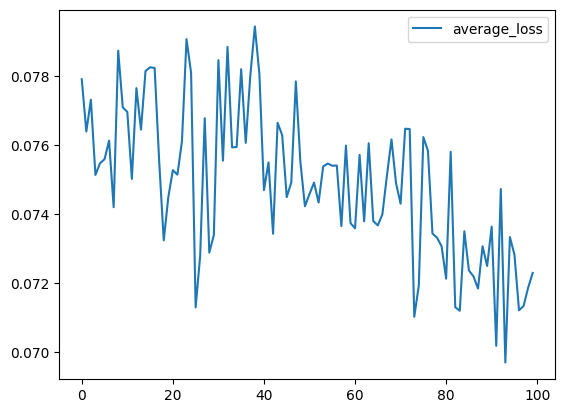

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 511=9.31980949640274
-------------------
######################################################################################
NOW: Training epoch:  512
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 512=9.128049580256144
-------------------
######################################################################################
NOW: Training epoch:  513
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 513=9.108831350008646
-------------------
######################################################################################
NOW: Training epoch:  514
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 514=9.237712287902832
-------------------
######################################################################################
NOW: Training epoch:  515
Loop over  193  batches (print . ever

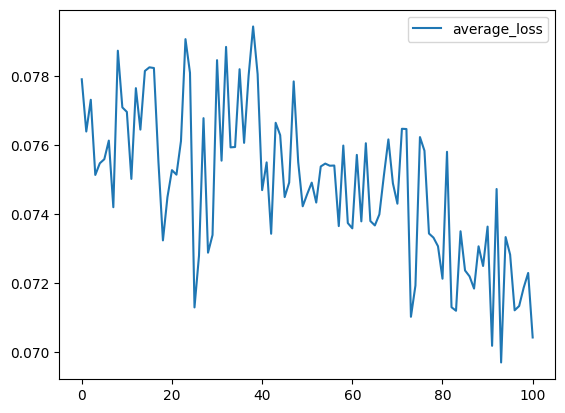

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 521=9.317188239097595
-------------------
######################################################################################
NOW: Training epoch:  522
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 522=9.324580522378286
-------------------
######################################################################################
NOW: Training epoch:  523
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 523=9.128974131743114
-------------------
######################################################################################
NOW: Training epoch:  524
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 524=9.146731634934744
-------------------
######################################################################################
NOW: Training epoch:  525
Loop over  193  batches (print . eve

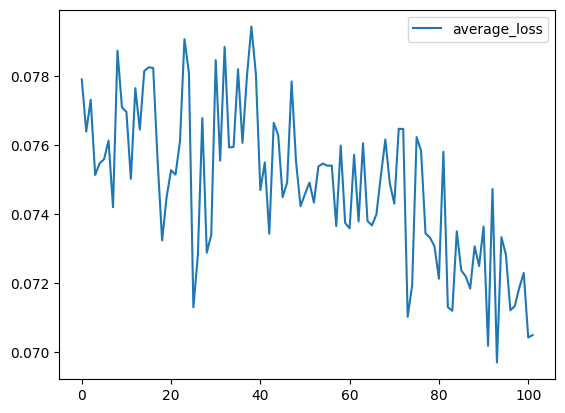

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 531=9.373131171862285
-------------------
######################################################################################
NOW: Training epoch:  532
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 532=9.417044727007548
-------------------
######################################################################################
NOW: Training epoch:  533
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 533=9.292407480875651
-------------------
######################################################################################
NOW: Training epoch:  534
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 534=9.146208322048187
-------------------
######################################################################################
NOW: Training epoch:  535
Loop over  193  batches (print . eve

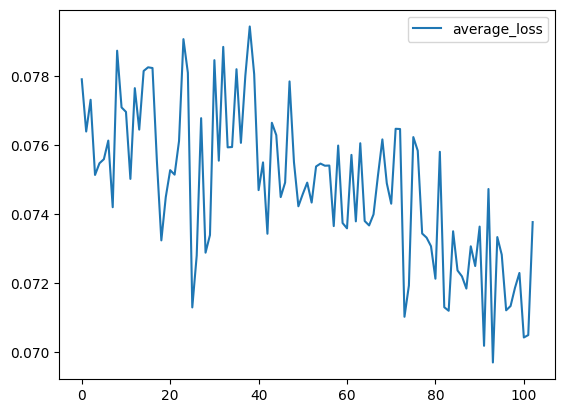

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 541=9.313474412759145
-------------------
######################################################################################
NOW: Training epoch:  542
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 542=9.290025130907695
-------------------
######################################################################################
NOW: Training epoch:  543
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 543=9.04966279665629
-------------------
######################################################################################
NOW: Training epoch:  544
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 544=9.05765661795934
-------------------
######################################################################################
NOW: Training epoch:  545
Loop over  193  batches (print . every

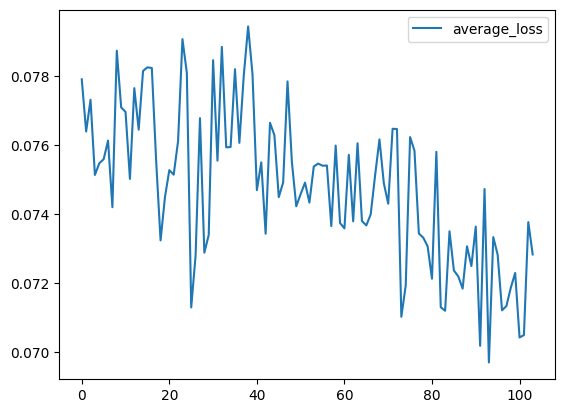

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 551=9.348340443770091
-------------------
######################################################################################
NOW: Training epoch:  552
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 552=9.324554022153219
-------------------
######################################################################################
NOW: Training epoch:  553
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 553=8.998026402791341
-------------------
######################################################################################
NOW: Training epoch:  554
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 554=9.270011246204376
-------------------
######################################################################################
NOW: Training epoch:  555
Loop over  193  batches (print . eve

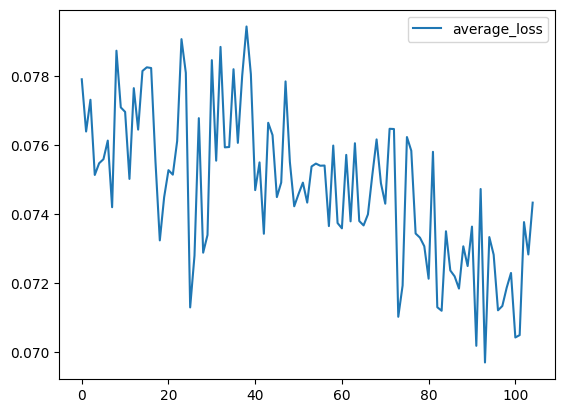

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 561=9.187322473526
-------------------
######################################################################################
NOW: Training epoch:  562
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 562=9.109874419371288
-------------------
######################################################################################
NOW: Training epoch:  563
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 563=8.962190842628479
-------------------
######################################################################################
NOW: Training epoch:  564
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 564=9.218244520823161
-------------------
######################################################################################
NOW: Training epoch:  565
Loop over  193  batches (print . every 

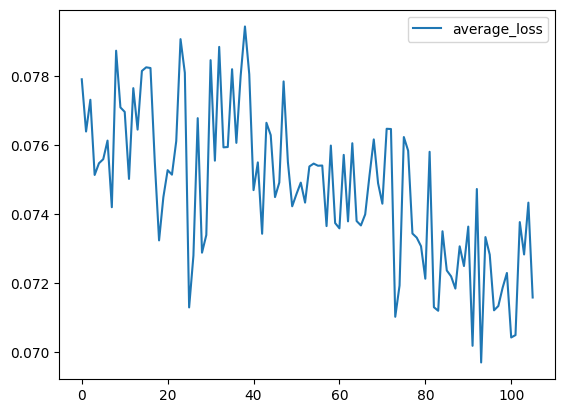

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 571=9.375093865394593
-------------------
######################################################################################
NOW: Training epoch:  572
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 572=9.22258002758026
-------------------
######################################################################################
NOW: Training epoch:  573
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 573=9.337692042191824
-------------------
######################################################################################
NOW: Training epoch:  574
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 574=9.390336227416991
-------------------
######################################################################################
NOW: Training epoch:  575
Loop over  193  batches (print . ever

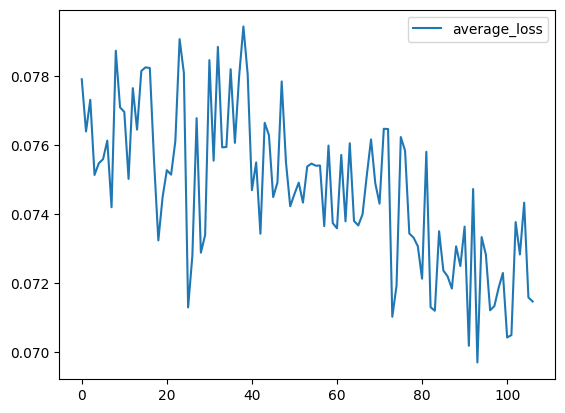

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 581=9.348041427135467
-------------------
######################################################################################
NOW: Training epoch:  582
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 582=9.312155981858572
-------------------
######################################################################################
NOW: Training epoch:  583
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 583=9.09347581466039
-------------------
######################################################################################
NOW: Training epoch:  584
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 584=9.32868154446284
-------------------
######################################################################################
NOW: Training epoch:  585
Loop over  193  batches (print . every

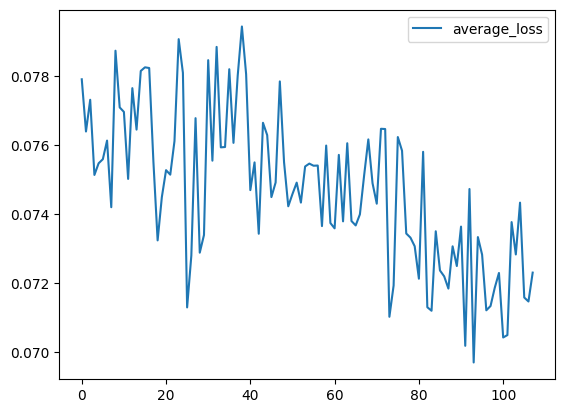

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 591=9.011988274256389
-------------------
######################################################################################
NOW: Training epoch:  592
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 592=9.185820945103963
-------------------
######################################################################################
NOW: Training epoch:  593
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 593=9.399689650535583
-------------------
######################################################################################
NOW: Training epoch:  594
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 594=9.191710674762726
-------------------
######################################################################################
NOW: Training epoch:  595
Loop over  193  batches (print . eve

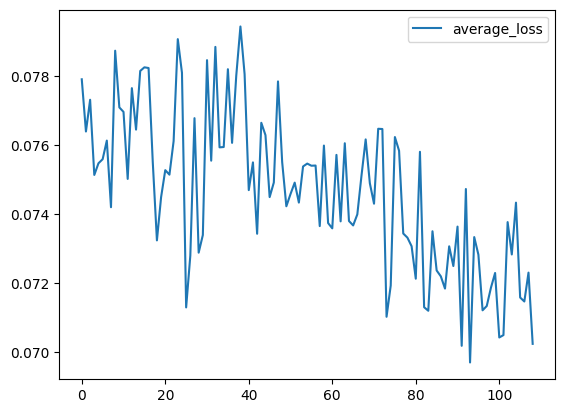

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 601=9.446137309074402
-------------------
######################################################################################
NOW: Training epoch:  602
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 602=9.23661776383718
-------------------
######################################################################################
NOW: Training epoch:  603
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 603=9.278271412849426
-------------------
######################################################################################
NOW: Training epoch:  604
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 604=9.292893819014232
-------------------
######################################################################################
NOW: Training epoch:  605
Loop over  193  batches (print . ever

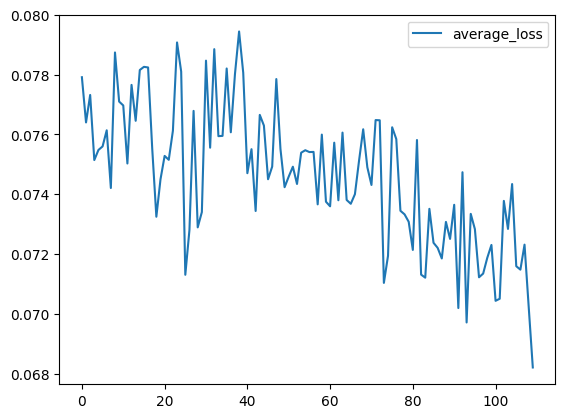

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 611=9.272671806812287
-------------------
######################################################################################
NOW: Training epoch:  612
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 612=9.478010420004527
-------------------
######################################################################################
NOW: Training epoch:  613
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 613=9.080999155839285
-------------------
######################################################################################
NOW: Training epoch:  614
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 614=8.974325998624165
-------------------
######################################################################################
NOW: Training epoch:  615
Loop over  193  batches (print . eve

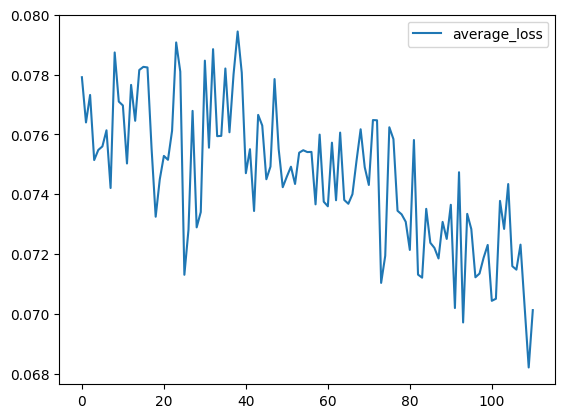

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 621=9.283286301294963
-------------------
######################################################################################
NOW: Training epoch:  622
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 622=9.098734295368194
-------------------
######################################################################################
NOW: Training epoch:  623
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 623=9.191608734925587
-------------------
######################################################################################
NOW: Training epoch:  624
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 624=9.550864831606548
-------------------
######################################################################################
NOW: Training epoch:  625
Loop over  193  batches (print . eve

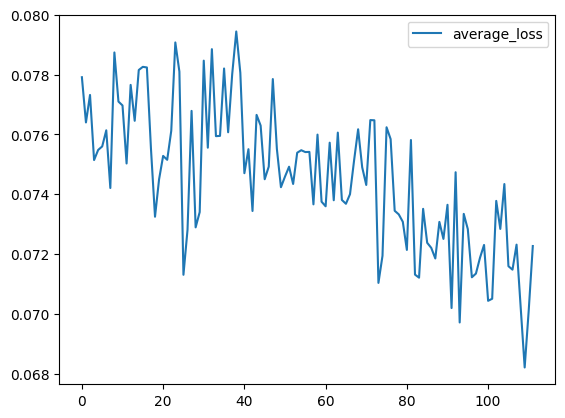

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 631=9.30703898270925
-------------------
######################################################################################
NOW: Training epoch:  632
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 632=8.977881034215292
-------------------
######################################################################################
NOW: Training epoch:  633
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 633=9.184920863310497
-------------------
######################################################################################
NOW: Training epoch:  634
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 634=9.402647205193837
-------------------
######################################################################################
NOW: Training epoch:  635
Loop over  193  batches (print . ever

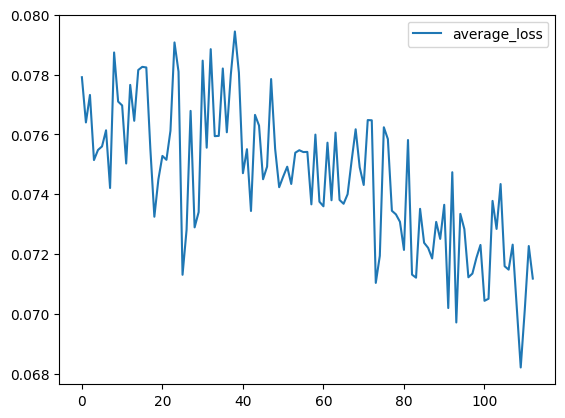

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 641=9.207908415794373
-------------------
######################################################################################
NOW: Training epoch:  642
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 642=9.241402403513591
-------------------
######################################################################################
NOW: Training epoch:  643
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 643=9.439871895313264
-------------------
######################################################################################
NOW: Training epoch:  644
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 644=9.402116000652313
-------------------
######################################################################################
NOW: Training epoch:  645
Loop over  193  batches (print . eve

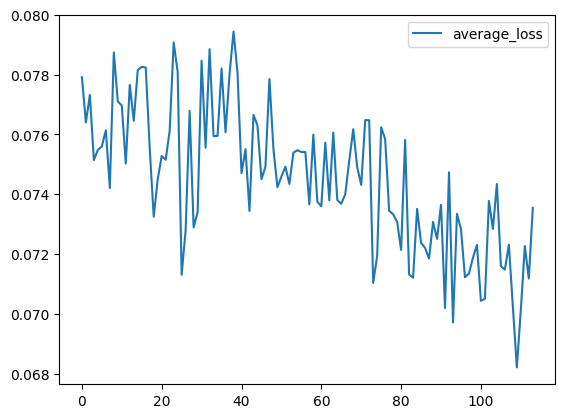

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 651=9.482310632864634
-------------------
######################################################################################
NOW: Training epoch:  652
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 652=9.183331505457561
-------------------
######################################################################################
NOW: Training epoch:  653
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 653=9.295736956596375
-------------------
######################################################################################
NOW: Training epoch:  654
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 654=9.29423257112503
-------------------
######################################################################################
NOW: Training epoch:  655
Loop over  193  batches (print . ever

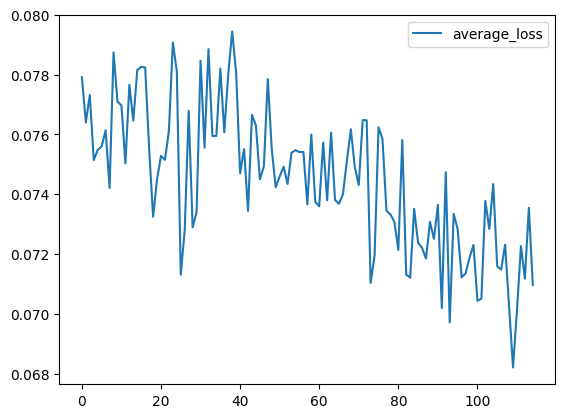

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 661=9.156144507726033
-------------------
######################################################################################
NOW: Training epoch:  662
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 662=9.329118752479554
-------------------
######################################################################################
NOW: Training epoch:  663
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 663=9.270882753531138
-------------------
######################################################################################
NOW: Training epoch:  664
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 664=9.295097970962525
-------------------
######################################################################################
NOW: Training epoch:  665
Loop over  193  batches (print . eve

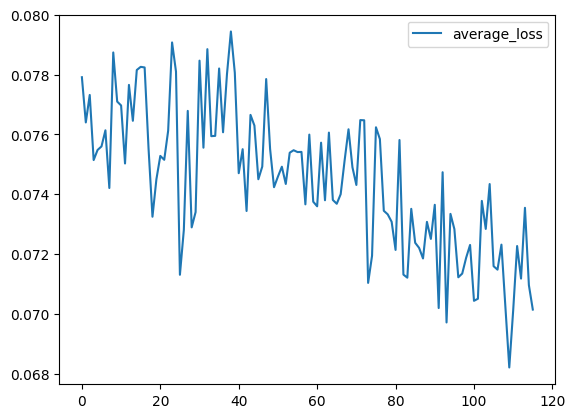

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 671=9.31342082420985
-------------------
######################################################################################
NOW: Training epoch:  672
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 672=9.402247631549836
-------------------
######################################################################################
NOW: Training epoch:  673
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 673=9.388588134447733
-------------------
######################################################################################
NOW: Training epoch:  674
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 674=9.1090105732282
-------------------
######################################################################################
NOW: Training epoch:  675
Loop over  193  batches (print . every 

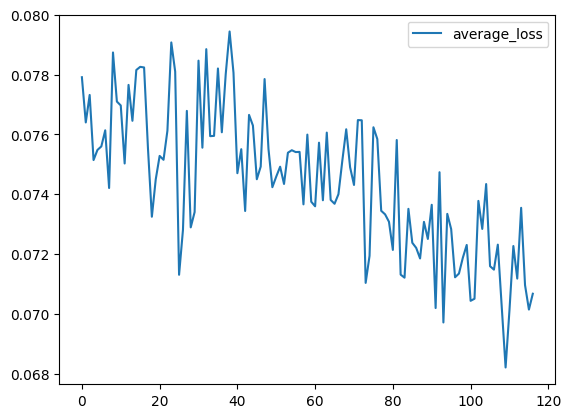

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 681=9.272018007437389
-------------------
######################################################################################
NOW: Training epoch:  682
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 682=9.302092758814494
-------------------
######################################################################################
NOW: Training epoch:  683
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 683=9.07710965871811
-------------------
######################################################################################
NOW: Training epoch:  684
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 684=9.173791507879892
-------------------
######################################################################################
NOW: Training epoch:  685
Loop over  193  batches (print . ever

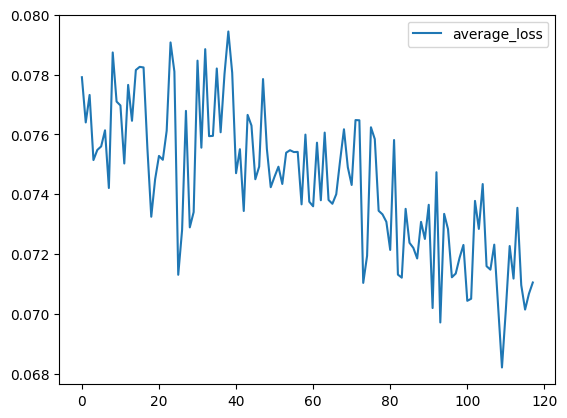

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 691=9.163646245002747
-------------------
######################################################################################
NOW: Training epoch:  692
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 692=9.477775331338247
-------------------
######################################################################################
NOW: Training epoch:  693
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 693=9.388751939932506
-------------------
######################################################################################
NOW: Training epoch:  694
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 694=9.299232117335002
-------------------
######################################################################################
NOW: Training epoch:  695
Loop over  193  batches (print . eve

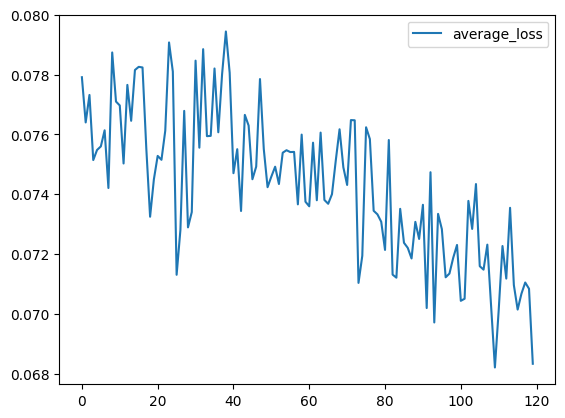

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 711=9.41160306930542
-------------------
######################################################################################
NOW: Training epoch:  712
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 712=9.38752485513687
-------------------
######################################################################################
NOW: Training epoch:  713
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 713=9.03324098587036
-------------------
######################################################################################
NOW: Training epoch:  714
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 714=9.22143462896347
-------------------
######################################################################################
NOW: Training epoch:  715
Loop over  193  batches (print . every  

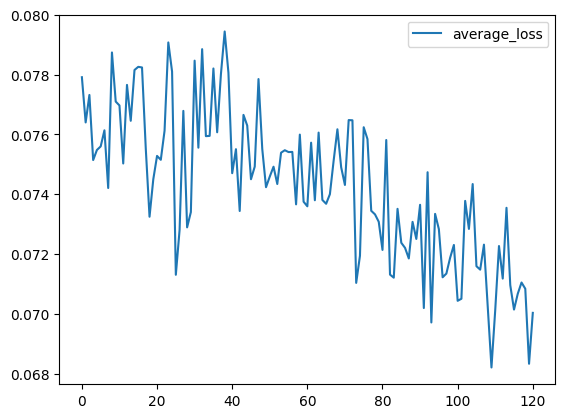

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 721=9.406619314352671
-------------------
######################################################################################
NOW: Training epoch:  722
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 722=9.37035051981608
-------------------
######################################################################################
NOW: Training epoch:  723
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 723=9.281555922826131
-------------------
######################################################################################
NOW: Training epoch:  724
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 724=9.373918517430623
-------------------
######################################################################################
NOW: Training epoch:  725
Loop over  193  batches (print . ever

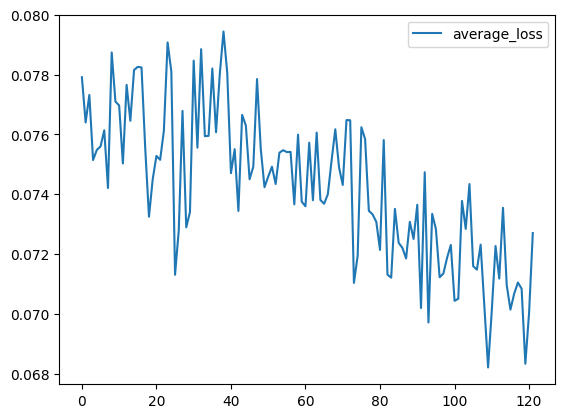

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 731=9.267829008897145
-------------------
######################################################################################
NOW: Training epoch:  732
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 732=9.232088088989258
-------------------
######################################################################################
NOW: Training epoch:  733
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 733=9.270640643437703
-------------------
######################################################################################
NOW: Training epoch:  734
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 734=9.280090761184692
-------------------
######################################################################################
NOW: Training epoch:  735
Loop over  193  batches (print . eve

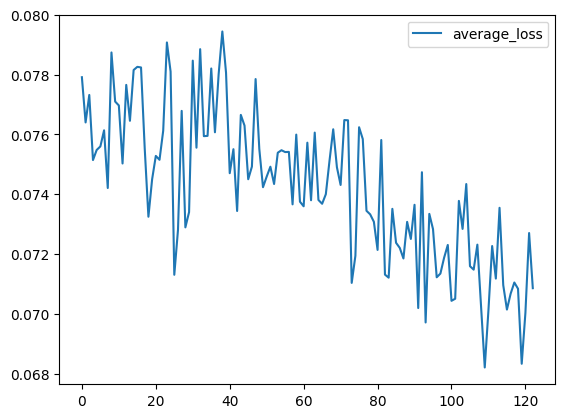

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 741=9.398392188549042
-------------------
######################################################################################
NOW: Training epoch:  742
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 742=9.258517901102701
-------------------
######################################################################################
NOW: Training epoch:  743
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 743=9.310881618658701
-------------------
######################################################################################
NOW: Training epoch:  744
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 744=9.401140371958414
-------------------
######################################################################################
NOW: Training epoch:  745
Loop over  193  batches (print . eve

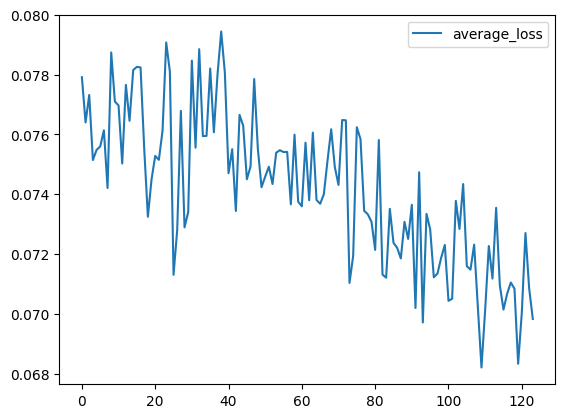

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 751=9.547912100950876
-------------------
######################################################################################
NOW: Training epoch:  752
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 752=9.376789740721385
-------------------
######################################################################################
NOW: Training epoch:  753
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 753=9.199275231361389
-------------------
######################################################################################
NOW: Training epoch:  754
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 754=9.437604486942291
-------------------
######################################################################################
NOW: Training epoch:  755
Loop over  193  batches (print . eve

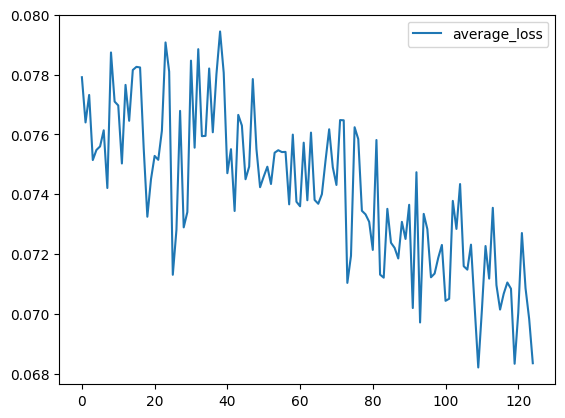

Producing 1 samples...
Model saved: 


-------------------
Time for epoch 761=9.225861418247224
-------------------
######################################################################################
NOW: Training epoch:  762
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 762=9.270361538728078
-------------------
######################################################################################
NOW: Training epoch:  763
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 763=9.204544611771901
-------------------
######################################################################################
NOW: Training epoch:  764
Loop over  193  batches (print . every  1930  steps)


-------------------
Time for epoch 764=9.25900696516037
-------------------
######################################################################################
NOW: Training epoch:  765
Loop over  193  batches (print . ever

In [ ]:
train_loop (PPD,
            train_loader_2,
            test_loader,
            optimizer=optimizer,
            print_every=batch_num*10,
            epochs=2000,
            start_ep=0,
            start_step=0,
            train_unet_number=1,
            trainer=None,
            plot_unscaled=False,#if unscaled data is plotted
            max_batch_size =16,#if trainer....
            save_model=True,
            cond_scales=[1.], 
            num_samples=1,
            prefix='./output_model2/',
            need_sample=False
           )
with open('loss2.json', 'w') as json_file:  
    json.dump(loss_list, json_file)